# Parkinson MRI Late Fusion — Patient-Level Matched 35-Epoch Pipeline

This notebook is the patient-level counterpart of the image-level
late-fusion experiment.

## Matched training configuration

Each base CNN uses:

- `include_top=False`
- 10 frozen-backbone head-training epochs
- 25 partial fine-tuning epochs
- 35 total configured epochs

The global trainable-weight fusion model and sample-wise attention
fusion model each use 35 epochs.

The same logistic-regression stacking configuration is used as in the
image-level notebook.

## Important evaluation definition

Patients are separated before constructing image datasets. No patient
may occur in more than one split. Slice probabilities are aggregated
into one probability per patient for the primary patient-level metrics
and ROC curves.

In [18]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
!pip install -q scikit-learn pandas pillow joblib openpyxl

In [20]:
import os, re, gc, json, shutil, hashlib, zipfile, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import VGG16, DenseNet121, MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve
)
from sklearn.utils.class_weight import compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as error:
        print("GPU warning:", error)

print("TensorFlow:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Configuration

In [34]:
ZIP_PATH = Path(
    "/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_late_fusion_dataset_here/Parkinson_dataset.zip"
)

# Extract locally to avoid slow repeated reads from Google Drive.
LOCAL_EXTRACT_DIR = Path(
    "/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_dataset_unzip_here"
)

SAVE_ROOT = Path(
    "/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here"
)

# Exact test cohort recovered from the uploaded VGG16 patient-level ROC NPZ.
FIXED_TEST_PATIENT_IDS = [
    "101179",
    "101295",
    "101799",
    "102003",
    "113447",
    "130190",
    "149005",
    "162905",
]

FIXED_TEST_PATIENT_LABELS = {
    "101179": 1,
    "101295": 1,
    "101799": 1,
    "102003": 1,
    "113447": 0,
    "130190": 0,
    "149005": 0,
    "162905": 0,
}

IMG_SIZE = (224, 224)
BATCH_SIZE = 16
SEED = 42

FIXED_TEST_PATIENT_COUNT = 8
DEVELOPMENT_PATIENT_COUNT = 8

HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 25
TOTAL_BASE_MODEL_EPOCHS = HEAD_EPOCHS + FINE_TUNE_EPOCHS

HEAD_LR = 1e-4
FINE_TUNE_LR = 5e-6
USE_EARLY_STOPPING = False
EARLY_STOPPING_PATIENCE = 7

UNFREEZE_LAST_N = {
    "VGG16": 8,
    "DenseNet121": 30,
    "MobileNetV2": 20,
}

# Reuse is allowed only when the complete split fingerprint and
# the 35-epoch configuration match.
REUSE_CORRECTED_MODELS = False # Changed to False to force retraining

GLOBAL_FUSION_EPOCHS = 35
ATTENTION_FUSION_EPOCHS = 35

MANUAL_WEIGHTS = np.array(
    [0.25, 0.50, 0.25],
    dtype=np.float32,
)

CLASS_NAMES = [
    "healthy_dataset",
    "parkinson_dataset",
]

CLASS_INDICES = {
    "healthy_dataset": 0,
    "parkinson_dataset": 1,
}

SUPPORTED_EXTENSIONS = (
    ".png",
    ".jpg",
    ".jpeg",
    ".bmp",
    ".tif",
    ".tiff",
)

MODELS_DIR = SAVE_ROOT / "models"
FUSION_DIR = SAVE_ROOT / "fusion_models"
PREDICTIONS_DIR = SAVE_ROOT / "predictions"
REPORTS_DIR = SAVE_ROOT / "reports"
CONFUSION_DIR = SAVE_ROOT / "confusion_matrices"
GRAPHS_DIR = SAVE_ROOT / "graphs"
ROC_DIR = SAVE_ROOT / "roc_npz"
GRADCAM_DIR = SAVE_ROOT / "gradcam"
HISTORY_DIR = SAVE_ROOT / "history"
TABLES_DIR = SAVE_ROOT / "tables"
SPLIT_DIR = SAVE_ROOT / "patient_split"

for folder in [
    SAVE_ROOT,
    MODELS_DIR,
    FUSION_DIR,
    PREDICTIONS_DIR,
    REPORTS_DIR,
    CONFUSION_DIR,
    GRAPHS_DIR,
    ROC_DIR,
    GRADCAM_DIR,
    HISTORY_DIR,
    TABLES_DIR,
    SPLIT_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

# Runtime writes happen locally, then completed files are synchronized to Drive.
LOCAL_RUNTIME_ROOT = Path(
    "/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here_patient_level_data_results"
)
LOCAL_MODELS_DIR = LOCAL_RUNTIME_ROOT / "models"
LOCAL_HISTORY_DIR = LOCAL_RUNTIME_ROOT / "history"
LOCAL_BACKUP_DIR = LOCAL_RUNTIME_ROOT / "training_backups"
LOCAL_FUSION_DIR = LOCAL_RUNTIME_ROOT / "fusion_models"

for folder in [
    LOCAL_RUNTIME_ROOT,
    LOCAL_MODELS_DIR,
    LOCAL_HISTORY_DIR,
    LOCAL_BACKUP_DIR,
    LOCAL_FUSION_DIR,
]:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )

PATIENT_ASSIGNMENT_PATH = (
    SPLIT_DIR / "patient_split_assignments.csv"
)

MASTER_SPLIT_PATH = (
    SPLIT_DIR / "parkinson_master_patient_split.csv"
)

FIXED_TEST_PATIENTS_PATH = (
    SPLIT_DIR / "fixed_test_patient_ids.csv"
)

assert TOTAL_BASE_MODEL_EPOCHS == 35
assert len(FIXED_TEST_PATIENT_IDS) == FIXED_TEST_PATIENT_COUNT
assert set(FIXED_TEST_PATIENT_IDS) == set(FIXED_TEST_PATIENT_LABELS)

print("Output folder:", SAVE_ROOT)
print("Fixed test patients:", FIXED_TEST_PATIENT_IDS)
print("Base-model epoch schedule:", HEAD_EPOCHS, "+", FINE_TUNE_EPOCHS)
print("Total epochs per base model:", TOTAL_BASE_MODEL_EPOCHS)
print("Global fusion epochs:", GLOBAL_FUSION_EPOCHS)
print("Attention fusion epochs:", ATTENTION_FUSION_EPOCHS)
print("Early stopping enabled:", USE_EARLY_STOPPING)

Output folder: /content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here
Fixed test patients: ['101179', '101295', '101799', '102003', '113447', '130190', '149005', '162905']
Base-model epoch schedule: 10 + 25
Total epochs per base model: 35
Global fusion epochs: 35
Attention fusion epochs: 35
Early stopping enabled: False


## Serializable preprocessing and fusion layers

In [22]:
@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class VGG16Preprocess(layers.Layer):
    def call(self, inputs):
        return tf.keras.applications.vgg16.preprocess_input(inputs)

@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class DenseNetPreprocess(layers.Layer):
    def call(self, inputs):
        return tf.keras.applications.densenet.preprocess_input(inputs)

@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class MobileNetV2Preprocess(layers.Layer):
    def call(self, inputs):
        return tf.keras.applications.mobilenet_v2.preprocess_input(inputs)

@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class GlobalTrainableFusion(layers.Layer):
    def __init__(self, number_of_models=3, **kwargs):
        super().__init__(**kwargs)
        self.number_of_models = number_of_models

    def build(self, input_shape):
        self.raw_weights = self.add_weight(
            name="raw_fusion_weights",
            shape=(self.number_of_models,),
            initializer="zeros",
            trainable=True
        )
        super().build(input_shape)

    def call(self, inputs):
        weights = tf.nn.softmax(self.raw_weights)
        return tf.reduce_sum(inputs * weights, axis=1, keepdims=True)

    def get_config(self):
        config = super().get_config()
        config.update({"number_of_models": self.number_of_models})
        return config

@tf.keras.utils.register_keras_serializable(package="ParkinsonFusion")
class AttentionWeightedSum(layers.Layer):
    def call(self, inputs):
        probabilities, weights = inputs
        return tf.reduce_sum(
            probabilities * weights,
            axis=1,
            keepdims=True
        )

CUSTOM_OBJECTS = {
    "VGG16Preprocess": VGG16Preprocess,
    "DenseNetPreprocess": DenseNetPreprocess,
    "MobileNetV2Preprocess": MobileNetV2Preprocess,
    "GlobalTrainableFusion": GlobalTrainableFusion,
    "AttentionWeightedSum": AttentionWeightedSum
}

## Extract the dataset and create the image manifest

In [23]:
def locate_dataset_root(search_root):
    search_root = Path(search_root)
    candidates = [search_root] + [
        path for path in search_root.rglob("*") if path.is_dir()
    ]
    for candidate in candidates:
        if (
            (candidate / "healthy_dataset").is_dir()
            and (candidate / "parkinson_dataset").is_dir()
        ):
            return candidate
    raise FileNotFoundError(
        f"No folder containing both class directories was found under {search_root}"
    )

if not ZIP_PATH.exists():
    raise FileNotFoundError(f"Dataset ZIP not found: {ZIP_PATH}")

extract_required = True
if LOCAL_EXTRACT_DIR.exists():
    try:
        DATASET_ROOT = locate_dataset_root(LOCAL_EXTRACT_DIR)
        extract_required = False
    except FileNotFoundError:
        shutil.rmtree(LOCAL_EXTRACT_DIR)

if extract_required:
    LOCAL_EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, "r") as archive:
        archive.extractall(LOCAL_EXTRACT_DIR)
    DATASET_ROOT = locate_dataset_root(LOCAL_EXTRACT_DIR)

PATIENT_PATTERN = re.compile(
    r"(?:^|[/\\\\])PPMI[_-](\d+)",
    flags=re.IGNORECASE
)
SLICE_PATTERN = re.compile(
    r"_(\d+)_S\d+_I\d+\.[^.]+$",
    flags=re.IGNORECASE
)

def patient_id_from_path(filepath):
    match = PATIENT_PATTERN.search(str(filepath))
    if not match:
        raise ValueError(f"Cannot extract PPMI patient ID from: {filepath}")
    return str(match.group(1))

def slice_index_from_path(filepath):
    match = SLICE_PATTERN.search(Path(filepath).name)
    return int(match.group(1)) if match else np.nan

records = []
for class_name in CLASS_NAMES:
    class_root = DATASET_ROOT / class_name
    if not class_root.is_dir():
        raise FileNotFoundError(class_root)

    for filepath in sorted(class_root.rglob("*")):
        if filepath.is_file() and filepath.suffix.lower() in SUPPORTED_EXTENSIONS:
            records.append({
                "filepath": str(filepath),
                "filename": filepath.name,
                "patient_id": patient_id_from_path(filepath),
                "slice_index": slice_index_from_path(filepath),
                "class_name": class_name,
                "label": CLASS_INDICES[class_name]
            })

all_images_df = pd.DataFrame(records).sort_values(
    ["patient_id", "filepath"]
).reset_index(drop=True)

if all_images_df.empty:
    raise RuntimeError("No MRI images were found.")

if all_images_df["filepath"].duplicated().any():
    raise RuntimeError("Duplicate image paths were found.")

if not all(Path(path).exists() for path in all_images_df["filepath"]):
    raise FileNotFoundError("At least one collected image path does not exist.")

label_counts_per_patient = all_images_df.groupby("patient_id")["label"].nunique()
if (label_counts_per_patient > 1).any():
    raise RuntimeError("A patient occurs in both classes.")

patient_table = (
    all_images_df.groupby(["patient_id", "label", "class_name"], as_index=False)
    .agg(image_count=("filepath", "size"))
)

print("Dataset root:", DATASET_ROOT)
print("Images:", len(all_images_df))
print("Patients:", len(patient_table))
display(patient_table.groupby("class_name").agg(
    patients=("patient_id", "nunique"),
    images=("image_count", "sum")
).reset_index())

Dataset root: /content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_dataset_unzip_here/Parkinson_dataset
Images: 11120
Patients: 52


,class_name,patients,images
0,healthy_dataset,23,5560
1,parkinson_dataset,29,5560


## Create and verify the exact patient-level train/development/test split

In [24]:
def save_fixed_test_patient_table():
    fixed_table = pd.DataFrame(
        {
            "patient_id": FIXED_TEST_PATIENT_IDS,
            "expected_label": [
                FIXED_TEST_PATIENT_LABELS[patient_id]
                for patient_id in FIXED_TEST_PATIENT_IDS
            ],
            "source": (
                "vgg16_base_trainable_patient_level_roc.npz"
            ),
        }
    )

    fixed_table.to_csv(
        FIXED_TEST_PATIENTS_PATH,
        index=False,
    )

    return fixed_table


def build_fixed_test_patient_assignments(patients):
    patients = patients.copy()
    patients["patient_id"] = patients["patient_id"].astype(str)

    fixed_test_id_set = set(FIXED_TEST_PATIENT_IDS)
    available_patient_ids = set(patients["patient_id"])

    missing = sorted(
        fixed_test_id_set - available_patient_ids
    )

    if missing:
        raise RuntimeError(
            "The following required fixed test patients were not found "
            f"in the current dataset: {missing}"
        )

    fixed_test_patients = patients[
        patients["patient_id"].isin(fixed_test_id_set)
    ].copy()

    remaining_patients = patients[
        ~patients["patient_id"].isin(fixed_test_id_set)
    ].copy()

    if len(fixed_test_patients) != FIXED_TEST_PATIENT_COUNT:
        raise RuntimeError(
            "The matched fixed-test patient count is incorrect."
        )

    expected_labels = fixed_test_patients[
        "patient_id"
    ].map(FIXED_TEST_PATIENT_LABELS).astype(int)

    actual_labels = fixed_test_patients[
        "label"
    ].astype(int)

    if not np.array_equal(
        expected_labels.to_numpy(),
        actual_labels.to_numpy(),
    ):
        mismatch_table = fixed_test_patients[
            ["patient_id", "label", "class_name"]
        ].copy()

        mismatch_table["expected_label"] = expected_labels.to_numpy()

        raise RuntimeError(
            "At least one fixed test patient has a class label different "
            "from the uploaded reference NPZ:\n"
            + mismatch_table.to_string(index=False)
        )

    class_counts = fixed_test_patients[
        "label"
    ].value_counts().to_dict()

    if class_counts.get(0, 0) != 4 or class_counts.get(1, 0) != 4:
        raise RuntimeError(
            "The fixed test cohort must contain four healthy and "
            "four Parkinson patients."
        )

    if DEVELOPMENT_PATIENT_COUNT <= 0:
        raise ValueError(
            "DEVELOPMENT_PATIENT_COUNT must be positive."
        )

    if DEVELOPMENT_PATIENT_COUNT >= len(remaining_patients):
        raise ValueError(
            "DEVELOPMENT_PATIENT_COUNT must be smaller than the number "
            "of remaining patients."
        )

    train_patients, development_patients = train_test_split(
        remaining_patients,
        test_size=DEVELOPMENT_PATIENT_COUNT,
        random_state=SEED,
        stratify=remaining_patients["label"],
    )

    train_patients = train_patients.copy()
    development_patients = development_patients.copy()
    fixed_test_patients = fixed_test_patients.copy()

    train_patients["split"] = "train"
    development_patients["split"] = "development"
    fixed_test_patients["split"] = "test"

    return pd.concat(
        [
            train_patients,
            development_patients,
            fixed_test_patients,
        ],
        ignore_index=True,
    ).sort_values(
        ["split", "patient_id"]
    ).reset_index(drop=True)


def validate_saved_assignments(assignments, patients):
    assignments = assignments.copy()
    assignments["patient_id"] = assignments["patient_id"].astype(str)

    patients = patients.copy()
    patients["patient_id"] = patients["patient_id"].astype(str)

    required_columns = {
        "patient_id",
        "label",
        "class_name",
        "image_count",
        "split",
    }

    missing_columns = required_columns - set(assignments.columns)

    if missing_columns:
        raise RuntimeError(
            "Saved patient assignments are missing columns: "
            f"{sorted(missing_columns)}"
        )

    if set(assignments["patient_id"]) != set(patients["patient_id"]):
        raise RuntimeError(
            "Saved patient assignments do not match the current dataset."
        )

    if assignments["patient_id"].duplicated().any():
        raise RuntimeError(
            "A patient appears more than once in the assignment table."
        )

    if set(assignments["split"]) != {
        "train",
        "development",
        "test",
    }:
        raise RuntimeError(
            "The saved assignment contains invalid split names."
        )

    label_check = assignments.merge(
        patients[["patient_id", "label"]],
        on="patient_id",
        suffixes=("_saved", "_current"),
    )

    if not np.array_equal(
        label_check["label_saved"].to_numpy(),
        label_check["label_current"].to_numpy(),
    ):
        raise RuntimeError(
            "Saved and current patient labels differ."
        )

    saved_test_ids = sorted(
        assignments.loc[
            assignments["split"] == "test",
            "patient_id",
        ].astype(str).tolist()
    )

    if saved_test_ids != sorted(FIXED_TEST_PATIENT_IDS):
        raise RuntimeError(
            "The saved test patients do not match the required "
            "eight-patient reference cohort."
        )

    return assignments.sort_values(
        ["split", "patient_id"]
    ).reset_index(drop=True)


save_fixed_test_patient_table()

if PATIENT_ASSIGNMENT_PATH.exists():
    try:
        patient_assignments = pd.read_csv(
            PATIENT_ASSIGNMENT_PATH,
            dtype={"patient_id": str},
        )

        patient_assignments = validate_saved_assignments(
            patient_assignments,
            patient_table,
        )

        print(
            "Reusing the verified fixed-test patient assignment."
        )

    except Exception as error:
        print(
            "Existing patient assignment was not reusable:",
            error,
        )

        patient_assignments = (
            build_fixed_test_patient_assignments(
                patient_table
            )
        )

        patient_assignments.to_csv(
            PATIENT_ASSIGNMENT_PATH,
            index=False,
        )

        print(
            "Created a new verified fixed-test patient assignment."
        )

else:
    patient_assignments = (
        build_fixed_test_patient_assignments(
            patient_table
        )
    )

    patient_assignments.to_csv(
        PATIENT_ASSIGNMENT_PATH,
        index=False,
    )

    print(
        "Created a new verified fixed-test patient assignment."
    )


master_df = all_images_df.merge(
    patient_assignments[["patient_id", "split"]],
    on="patient_id",
    how="left",
    validate="many_to_one",
)

if master_df["split"].isna().any():
    raise RuntimeError(
        "Some images were not assigned to a split."
    )

train_df = master_df[
    master_df["split"] == "train"
].copy().reset_index(drop=True)

development_df = master_df[
    master_df["split"] == "development"
].copy().reset_index(drop=True)

test_df = master_df[
    master_df["split"] == "test"
].copy().reset_index(drop=True)

train_patients = set(train_df["patient_id"].astype(str))
development_patients = set(
    development_df["patient_id"].astype(str)
)
test_patients = set(test_df["patient_id"].astype(str))

if train_patients & development_patients:
    raise RuntimeError(
        "Patient overlap between training and development."
    )

if train_patients & test_patients:
    raise RuntimeError(
        "Patient overlap between training and testing."
    )

if development_patients & test_patients:
    raise RuntimeError(
        "Patient overlap between development and testing."
    )

if test_patients != set(FIXED_TEST_PATIENT_IDS):
    raise RuntimeError(
        "The final test cohort does not match the fixed reference IDs."
    )

if (
    len(train_df)
    + len(development_df)
    + len(test_df)
    != len(master_df)
):
    raise RuntimeError(
        "Split image counts do not sum to the complete dataset."
    )

master_df.to_csv(
    MASTER_SPLIT_PATH,
    index=False,
)

fingerprint_source = patient_assignments[
    ["patient_id", "label", "split"]
].astype(str).sort_values(
    ["patient_id", "split"]
)

SPLIT_FINGERPRINT = hashlib.sha256(
    pd.util.hash_pandas_object(
        fingerprint_source,
        index=False,
    ).values.tobytes()
).hexdigest()[:20]

split_summary = master_df.groupby(
    ["split", "class_name"]
).agg(
    images=("filepath", "size"),
    patients=("patient_id", "nunique"),
).reset_index()

display(split_summary)

print("Training patients:", len(train_patients))
print("Development patients:", len(development_patients))
print("Test patients:", len(test_patients))
print("Fixed test patient IDs:", sorted(test_patients))
print("Train/development patient overlap: 0")
print("Train/test patient overlap: 0")
print("Development/test patient overlap: 0")
print("Total images included:", len(master_df))
print("Images excluded: 0")
print("Split fingerprint:", SPLIT_FINGERPRINT)
print("FIXED 8-PATIENT LEAKAGE CHECK: PASSED")

Reusing the verified fixed-test patient assignment.


,split,class_name,images,patients
0,development,healthy_dataset,768,3
1,development,parkinson_dataset,960,5
2,test,healthy_dataset,1148,4
3,test,parkinson_dataset,768,4
4,train,healthy_dataset,3644,16
5,train,parkinson_dataset,3832,20


Training patients: 36
Development patients: 8
Test patients: 8
Fixed test patient IDs: ['101179', '101295', '101799', '102003', '113447', '130190', '149005', '162905']
Train/development patient overlap: 0
Train/test patient overlap: 0
Development/test patient overlap: 0
Total images included: 11120
Images excluded: 0
Split fingerprint: 2c8672a648fb8e44d4f9
FIXED 8-PATIENT LEAKAGE CHECK: PASSED


## Deterministic TensorFlow datasets

In [25]:
AUTOTUNE = tf.data.AUTOTUNE

def decode_image(filepath, label):
    image = tf.io.decode_image(
        tf.io.read_file(filepath),
        channels=3,
        expand_animations=False
    )
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE, antialias=True)
    return tf.cast(image, tf.float32), tf.cast(label, tf.float32)

def create_dataset(dataframe, training=False):
    dataframe = dataframe.reset_index(drop=True)
    dataset = tf.data.Dataset.from_tensor_slices((
        dataframe["filepath"].astype(str).to_numpy(),
        dataframe["label"].to_numpy(dtype=np.float32)
    ))

    options = tf.data.Options()
    options.experimental_deterministic = True
    dataset = dataset.with_options(options)

    if training:
        dataset = dataset.shuffle(
            len(dataframe),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        decode_image,
        num_parallel_calls=AUTOTUNE,
        deterministic=True
    )
    return dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

train_ds = create_dataset(train_df, training=True)
development_ds = create_dataset(development_df)
test_ds = create_dataset(test_df)

class_weight_array = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["label"].to_numpy(dtype=np.int32)
)
CLASS_WEIGHTS = {
    0: float(class_weight_array[0]),
    1: float(class_weight_array[1])
}

sample_images, sample_labels = next(iter(train_ds))
if not np.all(np.isfinite(sample_images.numpy())):
    raise FloatingPointError("Decoded images contain invalid values.")

print("Class weights:", CLASS_WEIGHTS)
print("Sample batch:", sample_images.shape, sample_labels.shape)
print("INPUT PIPELINE CHECK: PASSED")

Class weights: {0: 1.0257958287596047, 1: 0.9754697286012526}
Sample batch: (16, 224, 224, 3) (16,)
INPUT PIPELINE CHECK: PASSED


## Build, train, and safely reuse corrected base models

In [26]:

def copy_file_with_retry(
    source,
    destination,
    attempts=5,
    initial_delay_seconds=2,
):
    source = Path(source)
    destination = Path(destination)

    if not source.exists():
        raise FileNotFoundError(
            f"Source file does not exist: {source}"
        )

    destination.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    delay = initial_delay_seconds
    last_error = None

    for attempt in range(1, attempts + 1):
        temporary_destination = destination.with_name(
            destination.name + ".copying"
        )

        try:
            if temporary_destination.exists():
                temporary_destination.unlink()

            shutil.copy2(
                source,
                temporary_destination,
            )

            temporary_destination.replace(
                destination
            )

            if (
                not destination.exists()
                or destination.stat().st_size
                != source.stat().st_size
            ):
                raise IOError(
                    "Copied file failed size verification."
                )

            return destination

        except Exception as error:
            last_error = error

            if temporary_destination.exists():
                try:
                    temporary_destination.unlink()
                except OSError:
                    pass

            print(
                f"Drive synchronization attempt {attempt}/{attempts} "
                f"failed for {destination.name}: {error}"
            )

            if attempt < attempts:
                time.sleep(delay)
                delay *= 2

    raise IOError(
        f"Unable to synchronize {source} to {destination}"
    ) from last_error


def write_text_locally_and_sync(
    text,
    local_path,
    drive_path,
):
    local_path = Path(local_path)
    local_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    local_path.write_text(
        text,
        encoding="utf-8",
    )

    copy_file_with_retry(
        local_path,
        drive_path,
    )


def ensure_checkpoint_exists(
    model,
    checkpoint_path,
):
    checkpoint_path = Path(checkpoint_path)

    if not checkpoint_path.exists():
        print(
            "No best checkpoint was written; "
            "saving the current weights as a fallback."
        )

        model.save_weights(
            checkpoint_path
        )

    return checkpoint_path


def create_backbone(model_name):
    common = {
        "include_top": False,
        "weights": "imagenet",
        "input_shape": (*IMG_SIZE, 3)
    }
    if model_name == "VGG16":
        return VGG16(**common, name="vgg16_backbone")
    if model_name == "DenseNet121":
        return DenseNet121(**common, name="densenet121_backbone")
    if model_name == "MobileNetV2":
        return MobileNetV2(**common, name="mobilenetv2_backbone")
    raise ValueError(model_name)

def preprocess_layer(model_name):
    if model_name == "VGG16":
        return VGG16Preprocess(name="vgg16_preprocess")
    if model_name == "DenseNet121":
        return DenseNetPreprocess(name="densenet121_preprocess")
    if model_name == "MobileNetV2":
        return MobileNetV2Preprocess(name="mobilenetv2_preprocess")
    raise ValueError(model_name)

def compile_base_model(model, learning_rate):
    model.compile(
        optimizer=keras.optimizers.Adam(
            learning_rate=learning_rate,
            clipnorm=1.0
        ),
        loss=keras.losses.BinaryCrossentropy(),
        metrics=[
            keras.metrics.BinaryAccuracy(name="accuracy"),
            keras.metrics.Precision(name="precision"),
            keras.metrics.Recall(name="recall"),
            keras.metrics.AUC(name="auc")
        ]
    )

def build_base_model(model_name):
    inputs = keras.Input(shape=(*IMG_SIZE, 3), name="image_input")
    x = keras.Sequential([
        layers.RandomRotation(0.02),
        layers.RandomZoom(0.05),
        layers.RandomTranslation(0.03, 0.03)
    ], name="augmentation")(inputs)

    x = preprocess_layer(model_name)(x)
    backbone = create_backbone(model_name)
    backbone.trainable = False
    x = backbone(x, training=False)

    x = layers.GlobalAveragePooling2D(
        name="global_average_pooling"
    )(x)
    x = layers.BatchNormalization(name="head_batch_norm")(x)
    x = layers.Dropout(0.35, name="head_dropout_1")(x)
    x = layers.Dense(256, activation="relu", name="head_dense_256")(x)
    x = layers.Dropout(0.25, name="head_dropout_2")(x)
    outputs = layers.Dense(
        1,
        activation="sigmoid",
        dtype="float32",
        name="prediction"
    )(x)

    model = keras.Model(
        inputs,
        outputs,
        name=f"{model_name}_patient_level_classifier"
    )
    compile_base_model(model, HEAD_LR)
    return model

def find_backbone(model, model_name):
    expected = {
        "VGG16": "vgg16_backbone",
        "DenseNet121": "densenet121_backbone",
        "MobileNetV2": "mobilenetv2_backbone"
    }[model_name]

    try:
        return model.get_layer(expected)
    except ValueError:
        signature = {
            "VGG16": "block5_conv3",
            "DenseNet121": "conv5_block16_2_conv",
            "MobileNetV2": "Conv_1"
        }[model_name]

        for layer in model.layers:
            if isinstance(layer, keras.Model):
                if any(sub.name == signature for sub in layer.layers):
                    return layer
        raise ValueError(f"Could not find {model_name} backbone.")

def set_fine_tuning(model, model_name):
    backbone = find_backbone(model, model_name)
    backbone.trainable = True

    for layer in backbone.layers:
        layer.trainable = False
    for layer in backbone.layers[-UNFREEZE_LAST_N[model_name]:]:
        layer.trainable = True
    for layer in backbone.layers:
        if isinstance(layer, layers.BatchNormalization):
            layer.trainable = False

    trainable = [layer.name for layer in backbone.layers if layer.trainable]
    if not trainable:
        raise RuntimeError(f"No {model_name} layers were unfrozen.")
    print(model_name, "trainable backbone layers:", trainable)

def make_callbacks(model_name, stage):
    checkpoint = LOCAL_MODELS_DIR / (
        f"{model_name.lower()}_{stage}_best.weights.h5"
    )

    csv_log = LOCAL_HISTORY_DIR / (
        f"{model_name.lower()}_{stage}.csv"
    )

    backup_directory = (
        LOCAL_BACKUP_DIR
        / model_name.lower()
        / stage
    )

    checkpoint.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    csv_log.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    backup_directory.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    callbacks = [
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_auc",
            mode="max",
            factor=0.5,
            patience=3,
            min_lr=1e-7,
            verbose=1
        ),
        keras.callbacks.ModelCheckpoint(
            str(checkpoint),
            monitor="val_auc",
            mode="max",
            save_best_only=True,
            save_weights_only=True,
            verbose=1
        ),
        keras.callbacks.CSVLogger(
            str(csv_log),
            append=False
        ),
        keras.callbacks.BackupAndRestore(
            backup_dir=str(
                backup_directory
            ),
            save_freq="epoch",
            delete_checkpoint=True
        )
    ]
    if USE_EARLY_STOPPING:
        callbacks.append(
            keras.callbacks.EarlyStopping(
                monitor="val_auc",
                mode="max",
                patience=EARLY_STOPPING_PATIENCE,
                restore_best_weights=False,
                verbose=1
            )
        )
    return callbacks, checkpoint

def history_dict(history):
    return {
        key: [float(value) for value in values]
        for key, values in history.history.items()
    }

def load_model_safely(path):
    try:
        return keras.models.load_model(
            path,
            custom_objects=CUSTOM_OBJECTS,
            compile=False,
            safe_mode=False
        )
    except TypeError:
        return keras.models.load_model(
            path,
            custom_objects=CUSTOM_OBJECTS,
            compile=False
        )

def train_or_load_model(model_name):
    final_path = MODELS_DIR / (
        f"{model_name.lower()}_patient_level_best.keras"
    )
    metadata_path = MODELS_DIR / (
        f"{model_name.lower()}_patient_level_metadata.json"
    )
    history_path = HISTORY_DIR / (
        f"{model_name.lower()}_combined_history.json"
    )

    if (
        REUSE_CORRECTED_MODELS
        and final_path.exists()
        and metadata_path.exists()
    ):
        metadata = json.loads(metadata_path.read_text())
        metadata_matches = (
            metadata.get("split_fingerprint") == SPLIT_FINGERPRINT
            and int(metadata.get("head_epochs", -1)) == HEAD_EPOCHS
            and int(metadata.get("fine_tune_epochs", -1)) == FINE_TUNE_EPOCHS
            and int(metadata.get("total_epochs", -1)) == TOTAL_BASE_MODEL_EPOCHS
        )

        if metadata_matches:
            model = load_model_safely(final_path)
            compile_base_model(model, FINE_TUNE_LR)
            history = (
                json.loads(history_path.read_text())
                if history_path.exists()
                else {}
            )
            print("Loaded corrected model:", final_path)
            return model, history

    tf.keras.backend.clear_session()
    gc.collect()

    # Remove stale runtime artifacts from a previous incomplete run.
    local_model_patterns = [
        f"{model_name.lower()}_head_best.weights.h5",
        f"{model_name.lower()}_fine_tune_best.weights.h5",
        f"{model_name.lower()}_patient_level_best.keras",
    ]

    for filename in local_model_patterns:
        candidate = LOCAL_MODELS_DIR / filename

        if candidate.exists():
            candidate.unlink()

    for stage in ["head", "fine_tune"]:
        candidate_csv = (
            LOCAL_HISTORY_DIR
            / f"{model_name.lower()}_{stage}.csv"
        )

        if candidate_csv.exists():
            candidate_csv.unlink()

        candidate_backup = (
            LOCAL_BACKUP_DIR
            / model_name.lower()
            / stage
        )

        if candidate_backup.exists():
            shutil.rmtree(
                candidate_backup
            )

    model = build_base_model(model_name)
    test_output = model(
        tf.zeros((1, *IMG_SIZE, 3), dtype=tf.float32),
        training=False
    )
    if test_output.shape != (1, 1):
        raise RuntimeError(f"Bad model output shape: {test_output.shape}")

    head_callbacks, head_checkpoint = make_callbacks(model_name, "head")
    head_history_object = model.fit(
        train_ds,
        validation_data=development_ds,
        epochs=HEAD_EPOCHS,
        class_weight=CLASS_WEIGHTS,
        callbacks=head_callbacks,
        verbose=1
    )
    head_history = history_dict(head_history_object)

    head_checkpoint = ensure_checkpoint_exists(
        model,
        head_checkpoint,
    )

    model.load_weights(
        head_checkpoint
    )

    copy_file_with_retry(
        head_checkpoint,
        MODELS_DIR / head_checkpoint.name,
    )

    head_csv = LOCAL_HISTORY_DIR / (
        f"{model_name.lower()}_head.csv"
    )

    if head_csv.exists():
        copy_file_with_retry(
            head_csv,
            HISTORY_DIR / head_csv.name,
        )

    set_fine_tuning(model, model_name)
    compile_base_model(model, FINE_TUNE_LR)

    fine_callbacks, fine_checkpoint = make_callbacks(
        model_name,
        "fine_tune"
    )
    fine_history_object = model.fit(
        train_ds,
        validation_data=development_ds,
        initial_epoch=HEAD_EPOCHS,
        epochs=HEAD_EPOCHS + FINE_TUNE_EPOCHS,
        class_weight=CLASS_WEIGHTS,
        callbacks=fine_callbacks,
        verbose=1
    )
    fine_history = history_dict(fine_history_object)

    fine_checkpoint = ensure_checkpoint_exists(
        model,
        fine_checkpoint,
    )

    copy_file_with_retry(
        fine_checkpoint,
        MODELS_DIR / fine_checkpoint.name,
    )

    fine_csv = LOCAL_HISTORY_DIR / (
        f"{model_name.lower()}_fine_tune.csv"
    )

    if fine_csv.exists():
        copy_file_with_retry(
            fine_csv,
            HISTORY_DIR / fine_csv.name,
        )

    head_auc = float(np.nanmax(head_history.get("val_auc", [-np.inf])))
    fine_auc = float(np.nanmax(fine_history.get("val_auc", [-np.inf])))

    if fine_auc >= head_auc:
        model.load_weights(fine_checkpoint)
        selected_stage = "fine_tune"
        selected_auc = fine_auc
    else:
        model.load_weights(head_checkpoint)
        selected_stage = "head"
        selected_auc = head_auc

    local_final_path = LOCAL_MODELS_DIR / final_path.name

    model.save(
        local_final_path
    )

    copy_file_with_retry(
        local_final_path,
        final_path,
    )

    combined = {}

    for current in [
        head_history,
        fine_history,
    ]:
        for key, values in current.items():
            combined.setdefault(
                key,
                [],
            ).extend(values)

    if len(combined.get("loss", [])) != TOTAL_BASE_MODEL_EPOCHS:
        raise RuntimeError(
            f"{model_name}: expected {TOTAL_BASE_MODEL_EPOCHS} "
            f"recorded epochs, got {len(combined.get('loss', []))}."
        )

    local_history_path = (
        LOCAL_HISTORY_DIR
        / history_path.name
    )

    write_text_locally_and_sync(
        json.dumps(
            combined,
            indent=2,
        ),
        local_history_path,
        history_path,
    )

    metadata = {
        "model_name": model_name,
        "split_fingerprint": SPLIT_FINGERPRINT,
        "selected_stage": selected_stage,
        "selected_validation_auc": selected_auc,
        "train_patients": len(train_patients),
        "development_patients": len(development_patients),
        "test_patients": len(test_patients),
        "fixed_test_patient_ids": sorted(test_patients),
        "head_epochs": HEAD_EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "total_epochs": TOTAL_BASE_MODEL_EPOCHS,
        "early_stopping_enabled": USE_EARLY_STOPPING,
        "checkpoint_storage": "local_colab_then_drive_sync",
    }

    local_metadata_path = (
        LOCAL_MODELS_DIR
        / metadata_path.name
    )

    write_text_locally_and_sync(
        json.dumps(
            metadata,
            indent=2,
        ),
        local_metadata_path,
        metadata_path,
    )

    print(
        "Saved verified 35-epoch patient-level model:",
        final_path,
    )
    return model, combined

BASE_MODEL_NAMES = ["VGG16", "DenseNet121", "MobileNetV2"]
base_models = {}
base_histories = {}

for model_name in BASE_MODEL_NAMES:
    base_models[model_name], base_histories[model_name] = (
        train_or_load_model(model_name)
    )

Loaded corrected model: /content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/models/vgg16_patient_level_best.keras
Loaded corrected model: /content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/models/densenet121_patient_level_best.keras
Loaded corrected model: /content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/models/mobilenetv2_patient_level_best.keras


## Training history graphs

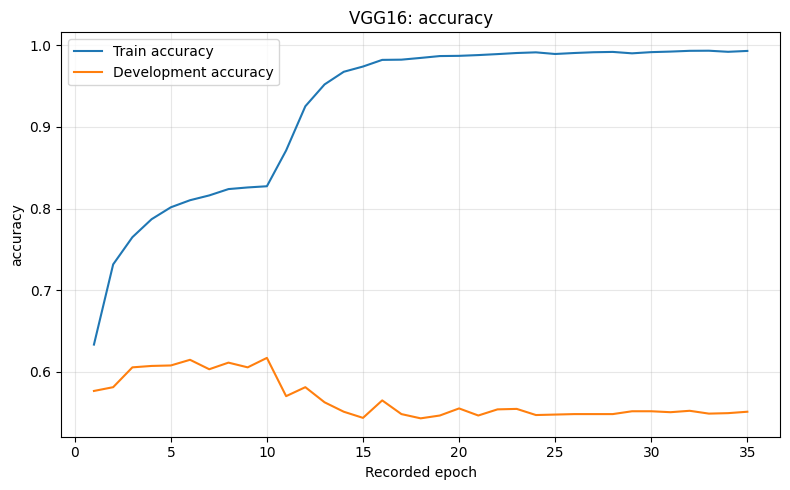

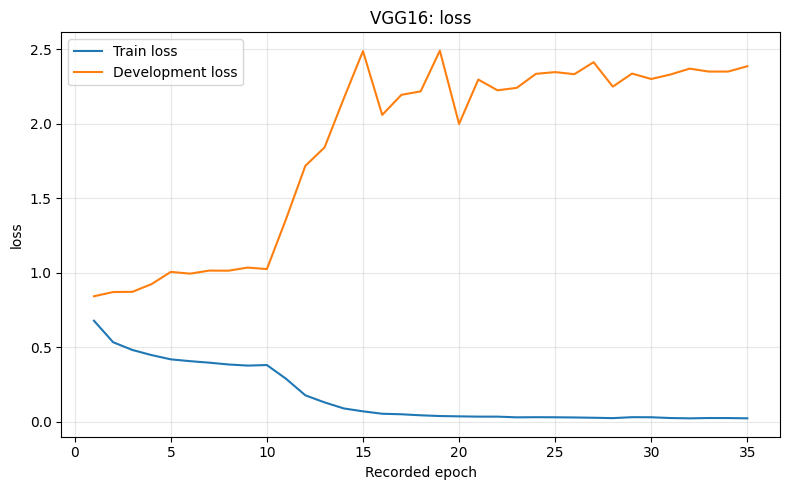

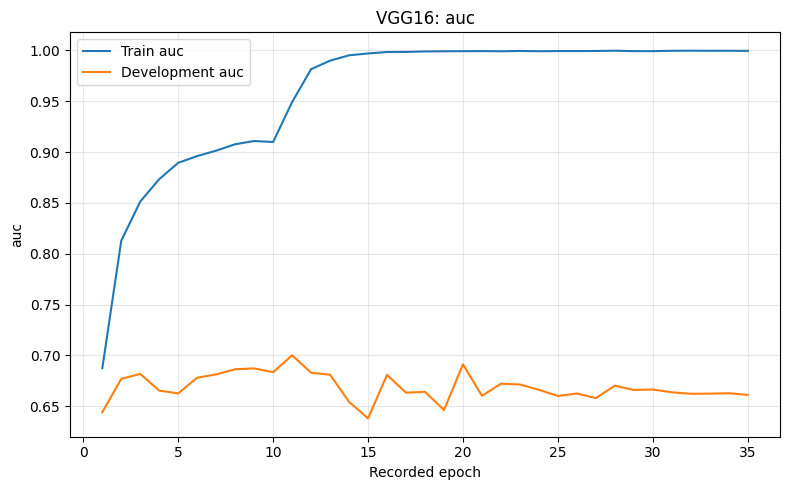

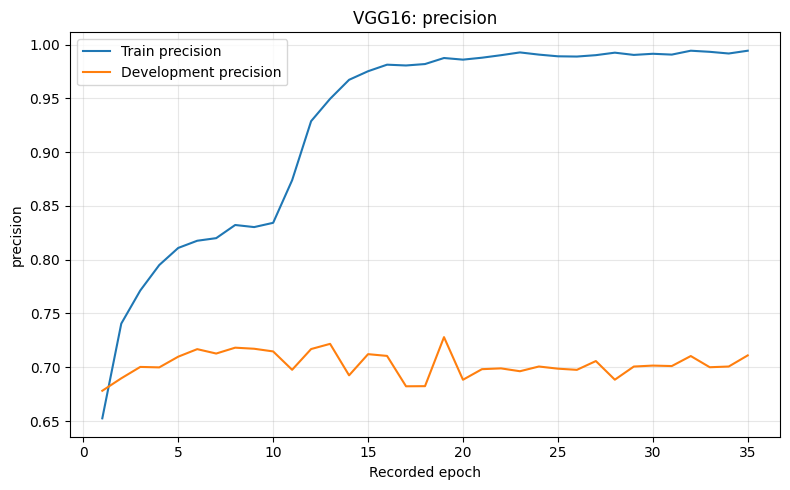

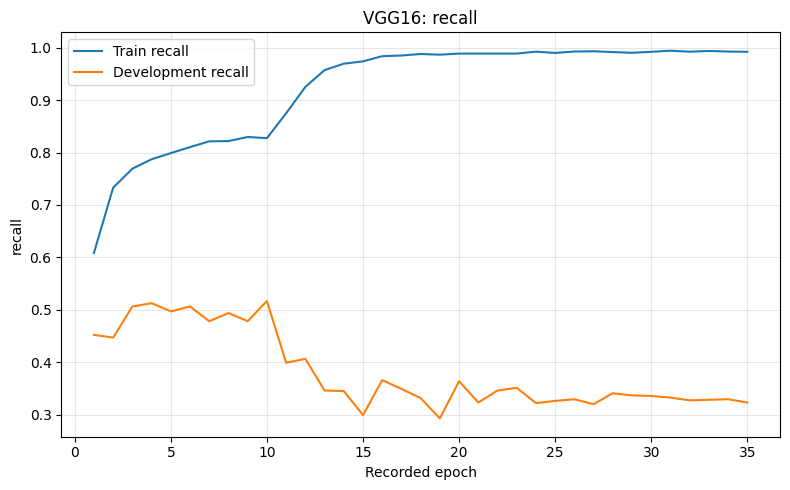

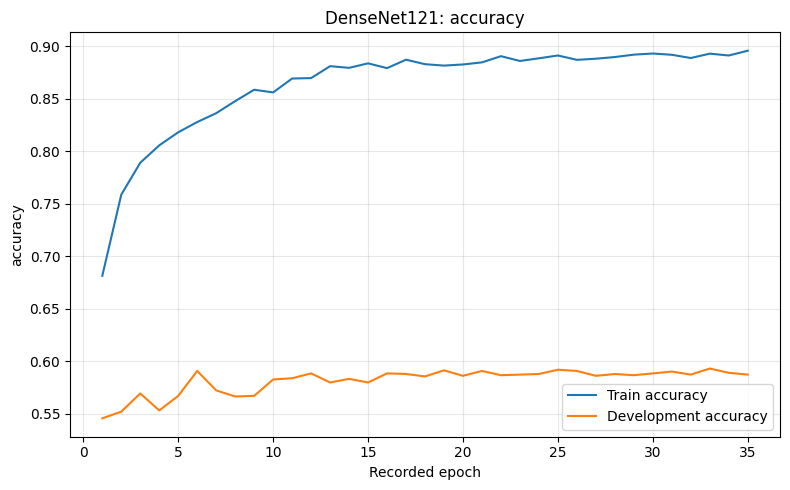

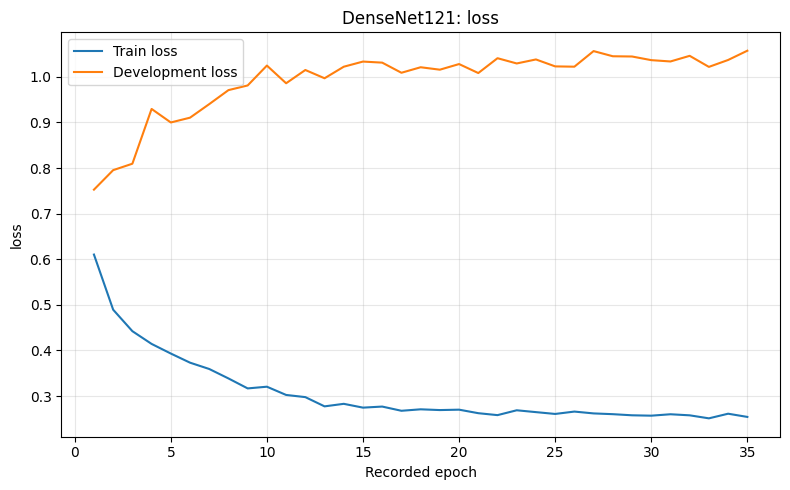

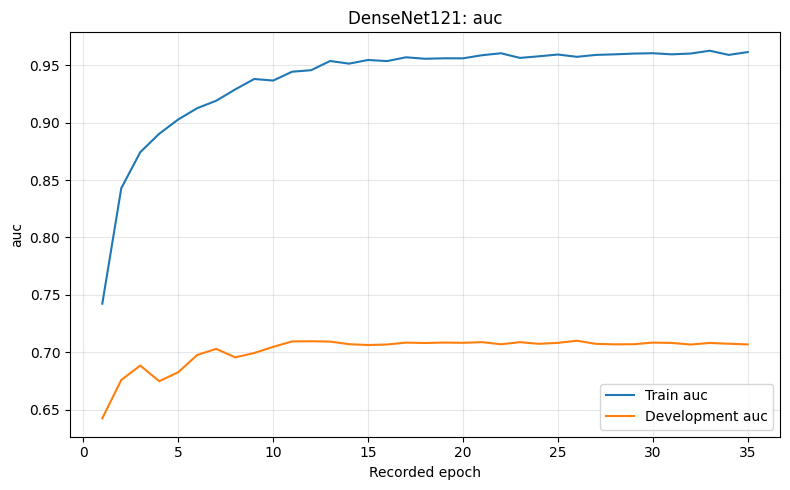

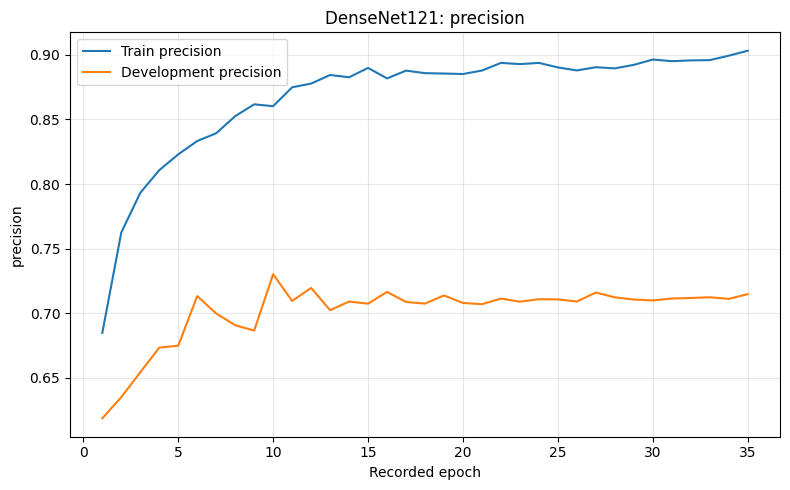

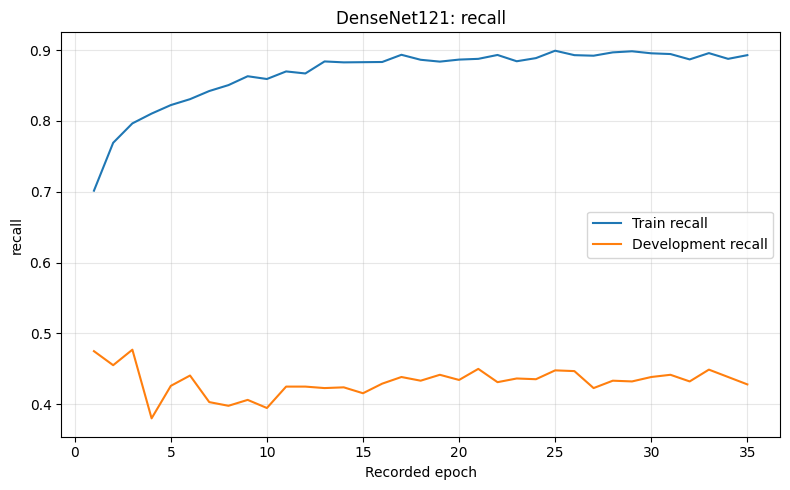

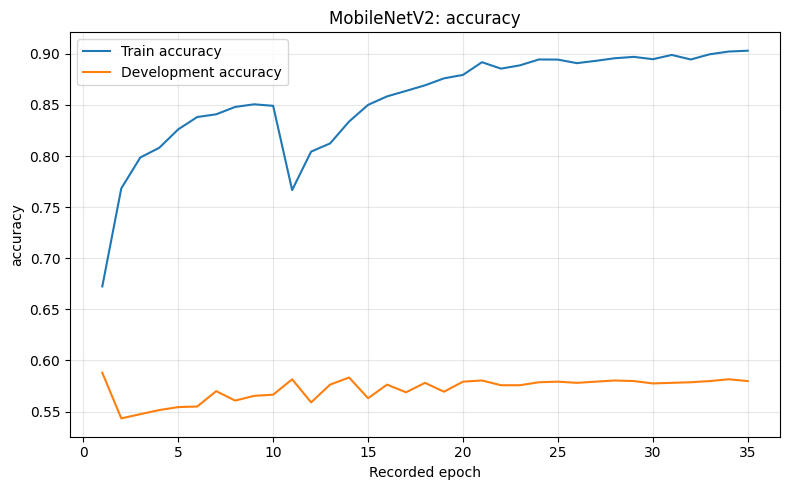

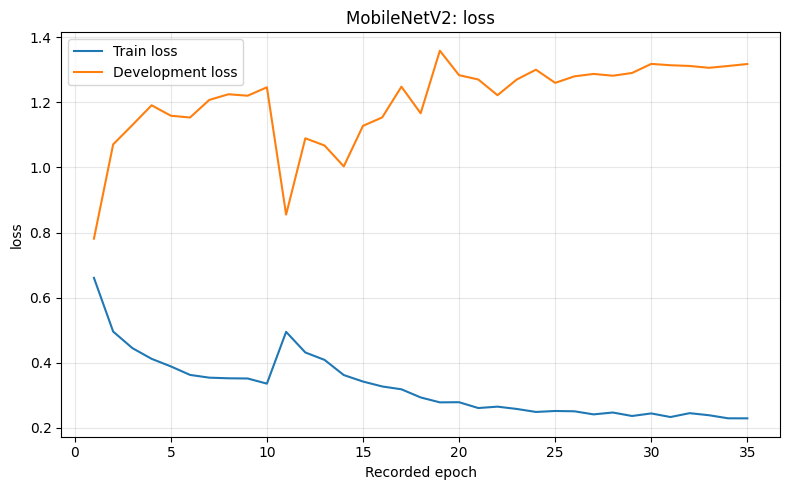

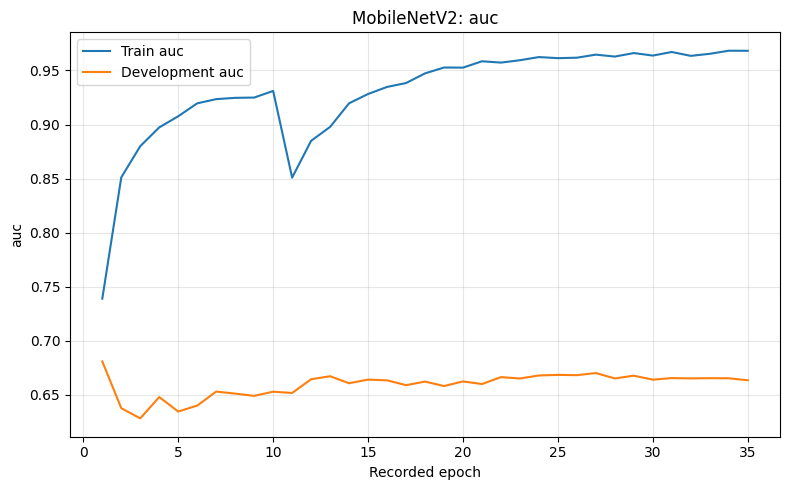

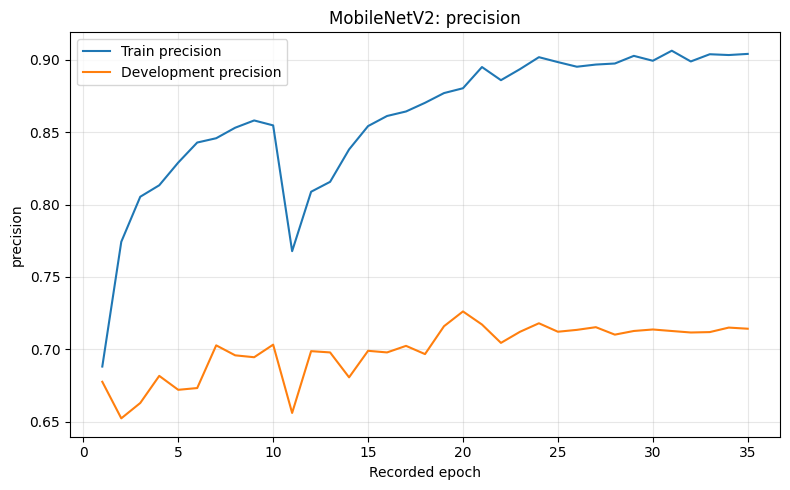

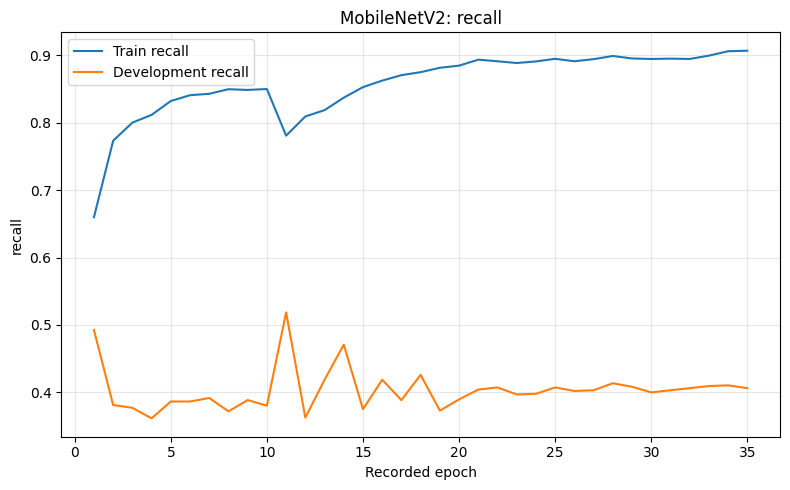

In [27]:
def plot_history(history, model_name, metric):
    train_values = history.get(metric, [])
    dev_values = history.get(f"val_{metric}", [])
    if not train_values or not dev_values:
        return

    epochs = np.arange(1, len(train_values) + 1)
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.plot(epochs, train_values, label=f"Train {metric}")
    axis.plot(epochs, dev_values, label=f"Development {metric}")
    axis.set_title(f"{model_name}: {metric}")
    axis.set_xlabel("Recorded epoch")
    axis.set_ylabel(metric)
    axis.grid(alpha=0.3)
    axis.legend()
    figure.tight_layout()
    figure.savefig(
        GRAPHS_DIR / f"{model_name.lower()}_{metric}.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()
    plt.close(figure)

for model_name, history in base_histories.items():
    for metric in ["accuracy", "loss", "auc", "precision", "recall"]:
        plot_history(history, model_name, metric)

## Generate aligned development and test probabilities

In [28]:
def predict_probabilities(model, dataset, expected_count, name):
    probabilities = np.asarray(
        model.predict(dataset, verbose=1),
        dtype=np.float32
    ).reshape(-1)

    if len(probabilities) != expected_count:
        raise RuntimeError(
            f"{name}: expected {expected_count}, got {len(probabilities)}"
        )
    if (
        not np.all(np.isfinite(probabilities))
        or np.any(probabilities < 0)
        or np.any(probabilities > 1)
    ):
        raise ValueError(f"{name}: invalid probabilities")
    return probabilities

development_table = development_df[
    ["filepath", "filename", "patient_id", "slice_index",
     "label", "class_name", "split"]
].copy()
test_table = test_df[
    ["filepath", "filename", "patient_id", "slice_index",
     "label", "class_name", "split"]
].copy()

probability_columns = {
    "VGG16": "vgg16_probability",
    "DenseNet121": "densenet121_probability",
    "MobileNetV2": "mobilenetv2_probability"
}

for model_name, column in probability_columns.items():
    development_table[column] = predict_probabilities(
        base_models[model_name],
        development_ds,
        len(development_df),
        f"{model_name} development"
    )
    test_table[column] = predict_probabilities(
        base_models[model_name],
        test_ds,
        len(test_df),
        f"{model_name} test"
    )

development_table.to_csv(
    PREDICTIONS_DIR / "development_base_probabilities.csv",
    index=False
)
test_table.to_csv(
    PREDICTIONS_DIR / "test_base_probabilities.csv",
    index=False
)

dev_ids = set(development_table["patient_id"])
test_ids = set(test_table["patient_id"])
if dev_ids & test_ids:
    raise RuntimeError("Patient overlap in probability tables.")

print("Development/test probability patient overlap: 0")
print("PROBABILITY ALIGNMENT CHECK: PASSED")

108/108 ━━━━━━━━━━━━━━━━━━━━ 43s 399ms/step
120/120 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step
120/120 ━━━━━━━━━━━━━━━━━━━━ 8s 68ms/step
108/108 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step
120/120 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step
Development/test probability patient overlap: 0
PROBABILITY ALIGNMENT CHECK: PASSED


## Fit late-fusion methods using development patients only (with the fixed 8-patient held-out test cohort)

Epoch 1/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5000 - auc: 0.6000 - loss: 0.7494 - precision: 0.6667 - recall: 0.4000
Epoch 2/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5000 - auc: 0.6000 - loss: 0.7486 - precision: 0.6667 - recall: 0.4000
Epoch 3/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.5000 - auc: 0.6000 - loss: 0.7478 - precision: 0.6667 - recall: 0.4000
Epoch 4/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5000 - auc: 0.6000 - loss: 0.7470 - precision: 0.6667 - recall: 0.4000
Epoch 5/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5000 - auc: 0.6000 - loss: 0.7462 - precision: 0.6667 - recall: 0.4000
Epoch 6/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 0.5000 - auc: 0.6000 - loss: 0.7454 - precision: 0.6667 - recall: 0.4000
Epoch 7/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5000 - auc: 0.6000 - loss: 0.7447 - precision: 0.6667 - recall: 0.4000
Epoch 8/35
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5

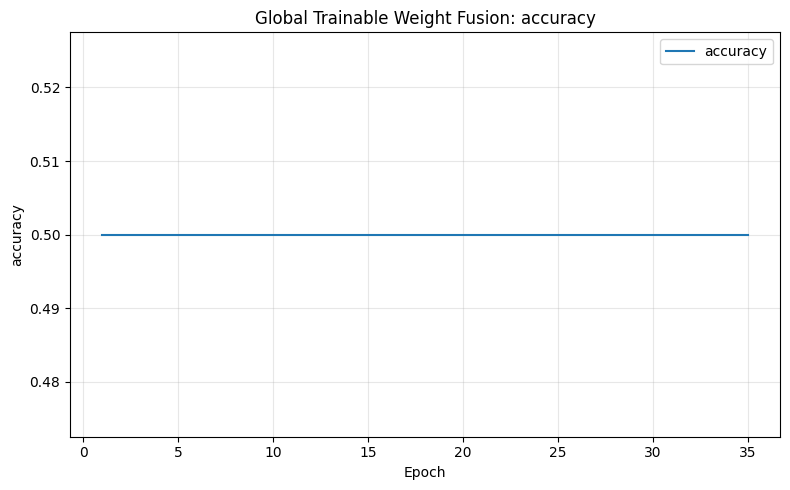

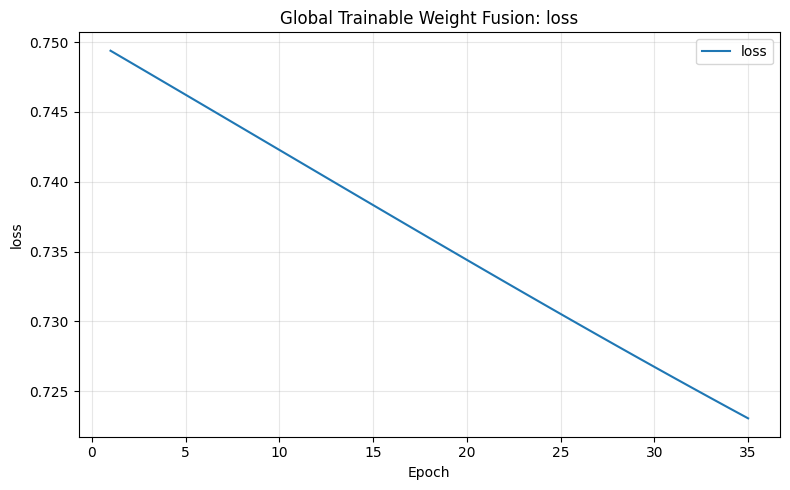

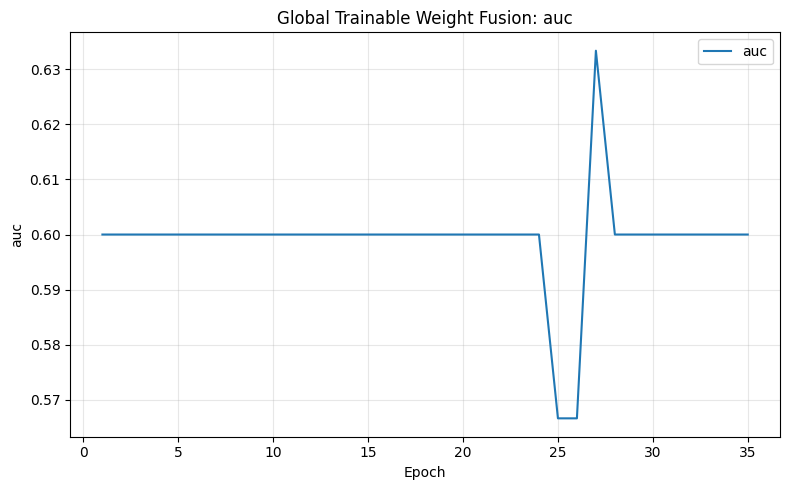

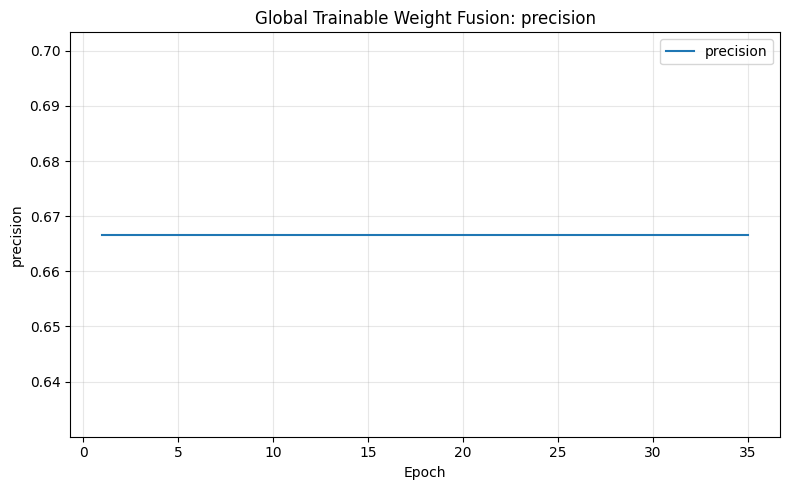

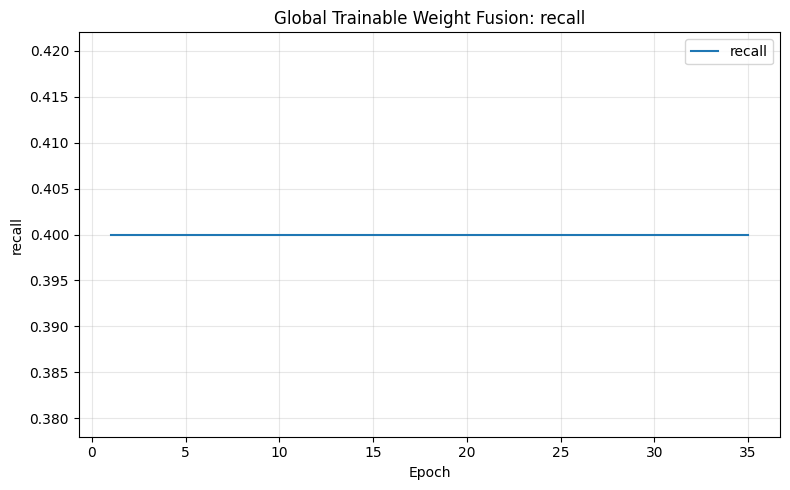

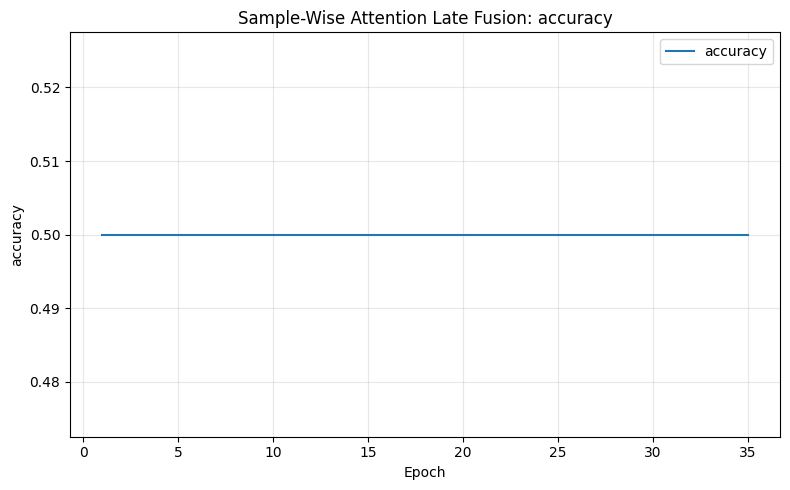

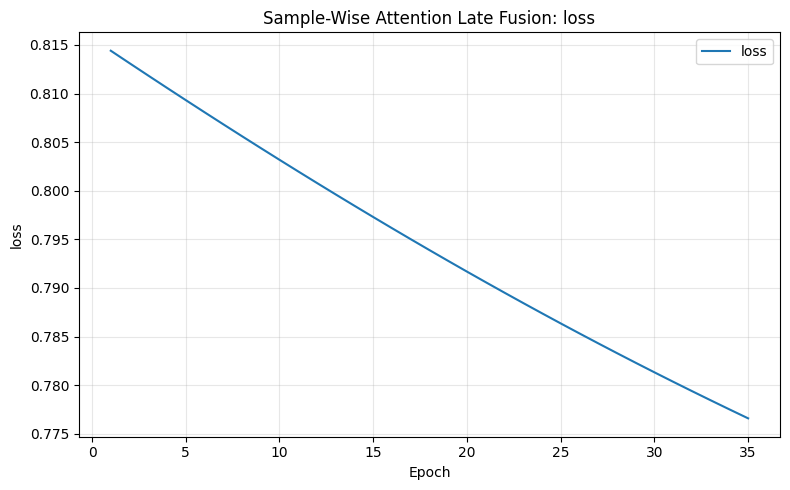

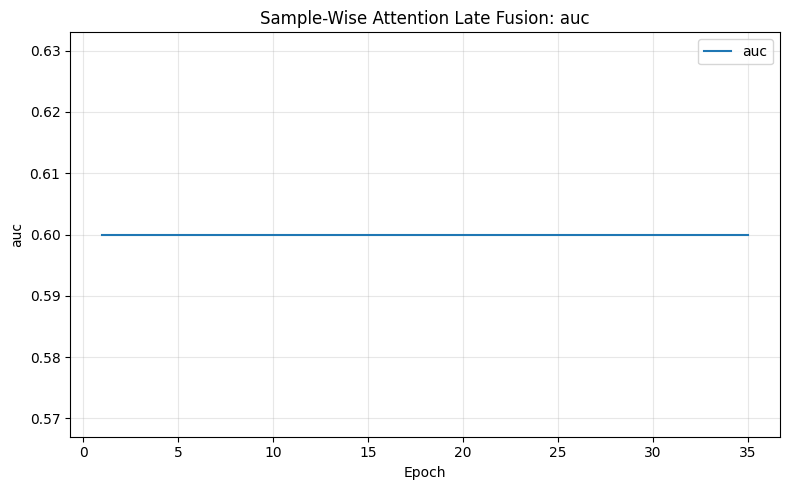

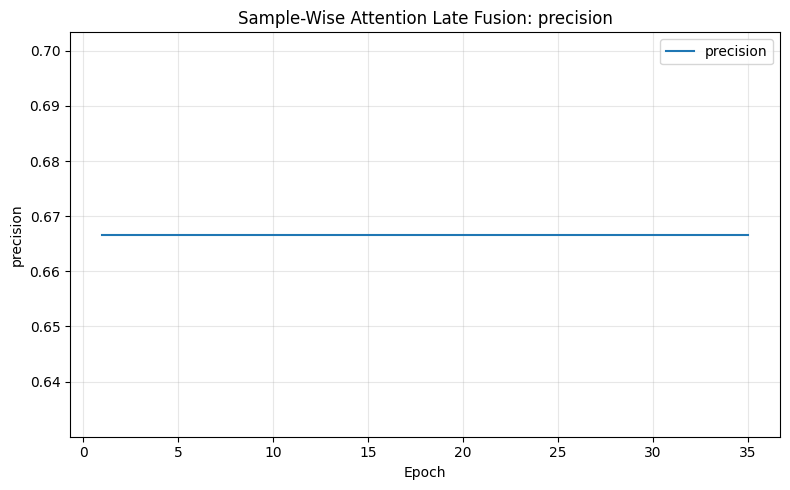

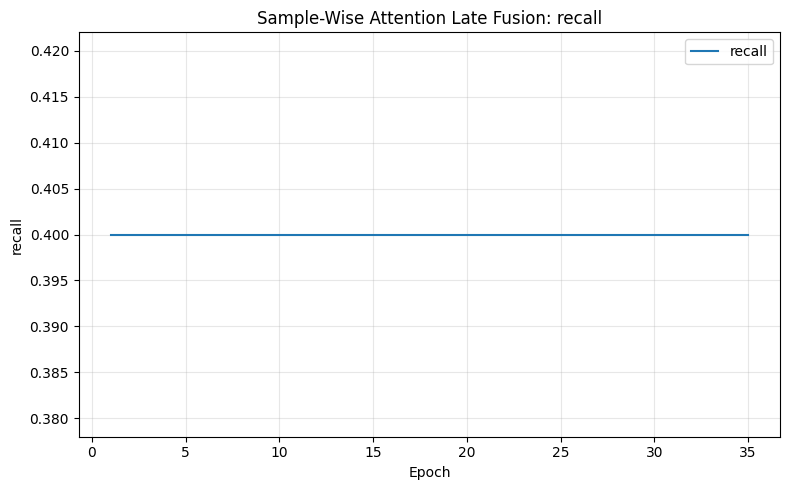

Global and attention late-fusion models completed 35 epochs.


In [35]:
PROBABILITY_COLUMNS = [
    "vgg16_probability",
    "densenet121_probability",
    "mobilenetv2_probability"
]

def aggregate_base_probabilities(table):
    return table.groupby(
        ["patient_id", "label", "class_name"],
        as_index=False
    ).agg(
        vgg16_probability=("vgg16_probability", "mean"),
        densenet121_probability=("densenet121_probability", "mean"),
        mobilenetv2_probability=("mobilenetv2_probability", "mean"),
        slice_count=("filepath", "size")
    )

development_patients_table = aggregate_base_probabilities(
    development_table
)
test_patients_table = aggregate_base_probabilities(test_table)

X_development = development_patients_table[
    PROBABILITY_COLUMNS
].to_numpy(dtype=np.float32)
y_development = development_patients_table[
    "label"
].to_numpy(dtype=np.int32)

X_test_slices = test_table[
    PROBABILITY_COLUMNS
].to_numpy(dtype=np.float32)
y_test_slices = test_table["label"].to_numpy(dtype=np.int32)

def safe_auc(y_true, y_prob):
    return (
        float(roc_auc_score(y_true, y_prob))
        if len(np.unique(y_true)) == 2
        else float("nan")
    )

def select_convex_weights(X, y, step=0.05):
    n = int(round(1 / step))
    best = None
    for first in range(n + 1):
        for second in range(n - first + 1):
            third = n - first - second
            weights = np.array(
                [first, second, third],
                dtype=np.float32
            ) / n
            probability = X @ weights
            prediction = (probability >= 0.5).astype(np.int32)
            score = (
                safe_auc(y, probability),
                float(f1_score(y, prediction, zero_division=0)),
                float(accuracy_score(y, prediction))
            )
            if best is None or score > best["score"]:
                best = {"weights": weights, "score": score}
    return best

grid_result = select_convex_weights(X_development, y_development)
GRID_WEIGHTS = grid_result["weights"]

global_input = keras.Input(shape=(3,), name="base_probabilities")
global_output = GlobalTrainableFusion(
    3,
    name="global_trainable_fusion"
)(global_input)
global_model = keras.Model(global_input, global_output)
global_model.compile(
    optimizer=keras.optimizers.Adam(0.01),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]
)
global_local_path = (
    LOCAL_FUSION_DIR
    / "global_trainable_fusion.keras"
)

global_drive_path = (
    FUSION_DIR
    / "global_trainable_fusion.keras"
)

if global_local_path.exists():
    global_local_path.unlink()

global_history = global_model.fit(
    X_development,
    y_development,
    epochs=GLOBAL_FUSION_EPOCHS,
    batch_size=min(16, len(X_development)),
    shuffle=True,
    callbacks=[
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ModelCheckpoint(
            str(global_local_path),
            monitor="loss",
            mode="min",
            save_best_only=True,
            verbose=0
        )
    ],
    verbose=1 # Changed to 1
)
if not global_local_path.exists():
    global_model.save(global_local_path)

global_model = load_model_safely(
    global_local_path
)

copy_file_with_retry(
    global_local_path,
    global_drive_path,
)
global_layer = global_model.get_layer("global_trainable_fusion")
GLOBAL_WEIGHTS = tf.nn.softmax(
    global_layer.raw_weights
).numpy()

attention_input = keras.Input(shape=(3,), name="base_probabilities")
attention_weights = layers.Dense(
    3,
    activation="softmax",
    kernel_regularizer=keras.regularizers.l2(0.02),
    bias_regularizer=keras.regularizers.l2(0.02),
    name="attention_weights"
)(attention_input)
attention_output = AttentionWeightedSum(
    name="attention_probability"
)([attention_input, attention_weights])
attention_model = keras.Model(attention_input, attention_output)
attention_model.compile(
    optimizer=keras.optimizers.Adam(0.005),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
    ]
)
attention_local_path = (
    LOCAL_FUSION_DIR
    / "attention_fusion.keras"
)

attention_drive_path = (
    FUSION_DIR
    / "attention_fusion.keras"
)

if attention_local_path.exists():
    attention_local_path.unlink()

attention_history = attention_model.fit(
    X_development,
    y_development,
    epochs=ATTENTION_FUSION_EPOCHS,
    batch_size=min(16, len(X_development)),
    shuffle=True,
    callbacks=[
        keras.callbacks.TerminateOnNaN(),
        keras.callbacks.ModelCheckpoint(
            str(attention_local_path),
            monitor="loss",
            mode="min",
            save_best_only=True,
            verbose=0
        )
    ],
    verbose=1 # Changed to 1
)
if not attention_local_path.exists():
    attention_model.save(
        attention_local_path
    )

attention_model = load_model_safely(
    attention_local_path
)

copy_file_with_retry(
    attention_local_path,
    attention_drive_path,
)

stacking_model = Pipeline([
    ("scaler", StandardScaler()),
    ("meta_classifier", LogisticRegression(
        C=0.10,
        class_weight="balanced",
        max_iter=3000,
        random_state=SEED
    ))
])
stacking_model.fit(X_development, y_development)
stacking_local_path = (
    LOCAL_FUSION_DIR
    / "logistic_stacking.joblib"
)

stacking_drive_path = (
    FUSION_DIR
    / "logistic_stacking.joblib"
)

if stacking_local_path.exists():
    stacking_local_path.unlink()

joblib.dump(
    stacking_model,
    stacking_local_path,
)

copy_file_with_retry(
    stacking_local_path,
    stacking_drive_path,
)

test_method_probabilities = {
    "VGG16": X_test_slices[:, 0],
    "DenseNet121": X_test_slices[:, 1],
    "MobileNetV2": X_test_slices[:, 2],
    "Equal Average Late Fusion": X_test_slices.mean(axis=1),
    "Manual Weighted Late Fusion": X_test_slices @ MANUAL_WEIGHTS,
    "Validation Grid Weighted Late Fusion": X_test_slices @ GRID_WEIGHTS,
    "Global Trainable Weight Fusion": np.asarray(
        global_model.predict(X_test_slices, verbose=0)
    ).reshape(-1),
    "Sample Wise Attention Late Fusion": np.asarray(
        attention_model.predict(X_test_slices, verbose=0)
    ).reshape(-1),
    "Logistic Regression Stacking": stacking_model.predict_proba(
        X_test_slices
    )[:, 1]
}

attention_extractor = keras.Model(
    attention_model.input,
    attention_model.get_layer("attention_weights").output
)
mean_attention_weights = attention_extractor.predict(
    X_development,
    verbose=0
).mean(axis=0)

pd.DataFrame({
    "Model": BASE_MODEL_NAMES,
    "Manual Weight": MANUAL_WEIGHTS,
    "Grid Selected Weight": GRID_WEIGHTS,
    "Global Learned Weight": GLOBAL_WEIGHTS,
    "Mean Development Attention Weight": mean_attention_weights
}).to_csv(TABLES_DIR / "late_fusion_weights.csv", index=False)

print("Grid-selected weights:", GRID_WEIGHTS)
print("Global learned weights:", GLOBAL_WEIGHTS)
print("All fusion methods were fitted without test patients.")


def plot_fusion_training_history(
    history,
    fusion_name,
    filename_prefix,
):
    history_dictionary = (
        history.history
        if hasattr(history, "history")
        else history
    )

    for metric in [
        "accuracy",
        "loss",
        "auc",
        "precision",
        "recall",
    ]:
        values = history_dictionary.get(
            metric,
            [],
        )

        if not values:
            continue

        epochs = np.arange(
            1,
            len(values) + 1,
        )

        figure, axis = plt.subplots(
            figsize=(8, 5)
        )

        axis.plot(
            epochs,
            values,
            label=metric,
        )

        axis.set_title(
            f"{fusion_name}: {metric}"
        )
        axis.set_xlabel("Epoch")
        axis.set_ylabel(metric)
        axis.grid(alpha=0.3)
        axis.legend()
        figure.tight_layout()

        graph_path = (
            GRAPHS_DIR
            / f"{filename_prefix}_{metric}.png"
        )

        figure.savefig(
            graph_path,
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()
        plt.close(figure)


plot_fusion_training_history(
    global_history,
    "Global Trainable Weight Fusion",
    "global_trainable_weight_fusion",
)

plot_fusion_training_history(
    attention_history,
    "Sample-Wise Attention Late Fusion",
    "sample_wise_attention_late_fusion",
)

global_history_table = pd.DataFrame(
    global_history.history
)

global_history_table.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(global_history_table) + 1,
    ),
)

global_history_table.to_csv(
    HISTORY_DIR
    / "global_trainable_weight_fusion_history.csv",
    index=False,
)

attention_history_table = pd.DataFrame(
    attention_history.history
)

attention_history_table.insert(
    0,
    "epoch",
    np.arange(
        1,
        len(attention_history_table) + 1,
    ),
)

attention_history_table.to_csv(
    HISTORY_DIR
    / "sample_wise_attention_late_fusion_history.csv",
    index=False,
)

if len(global_history.history.get("loss", [])) != GLOBAL_FUSION_EPOCHS:
    raise RuntimeError(
        "Global fusion did not complete all configured epochs."
    )

if len(attention_history.history.get("loss", [])) != ATTENTION_FUSION_EPOCHS:
    raise RuntimeError(
        "Attention fusion did not complete all configured epochs."
    )

print(
    "Global and attention late-fusion models completed 35 epochs."
)


## Evaluate every method at slice and patient levels

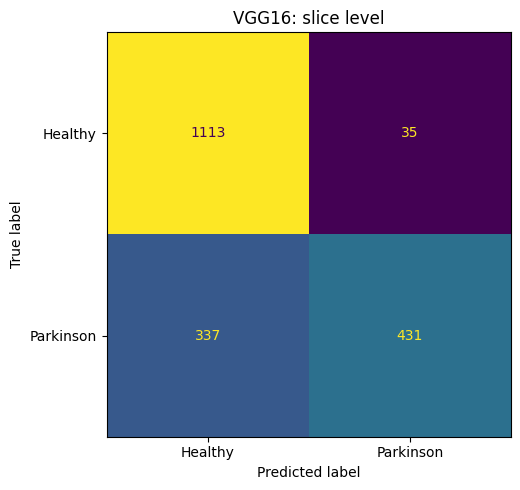

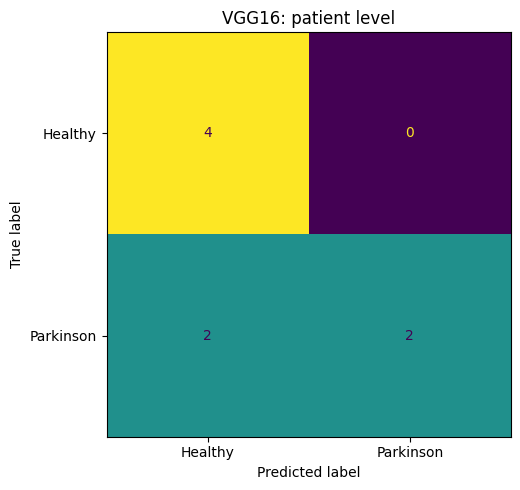

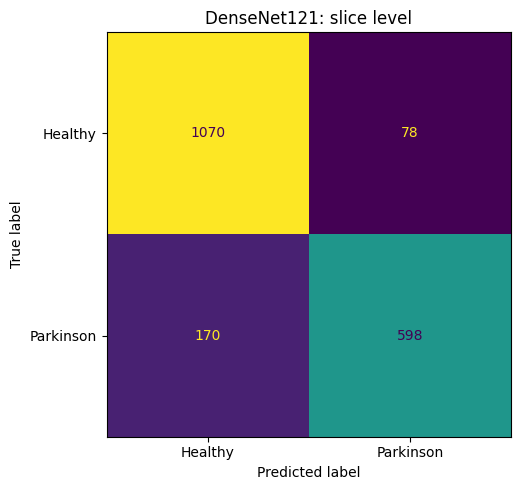

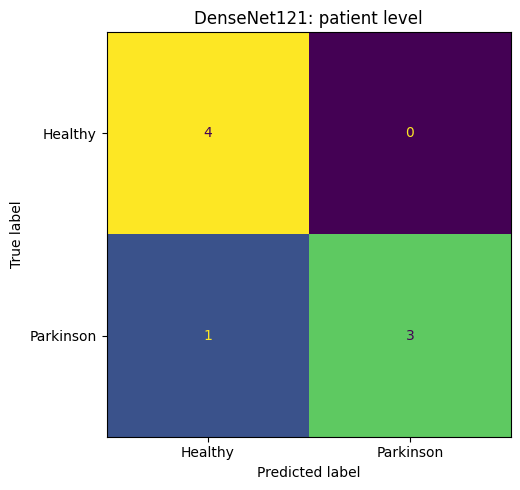

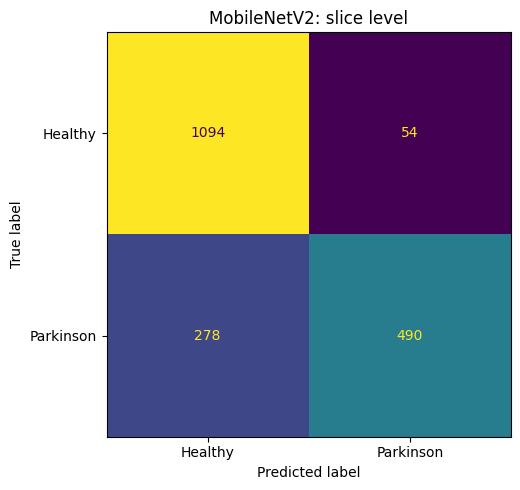

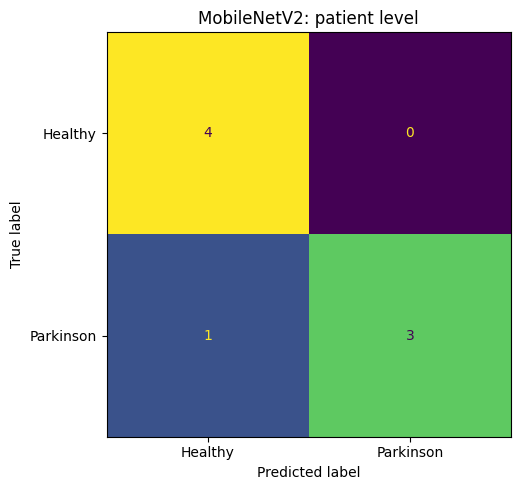

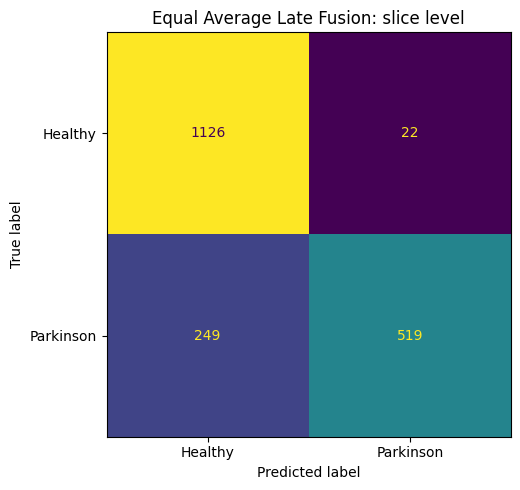

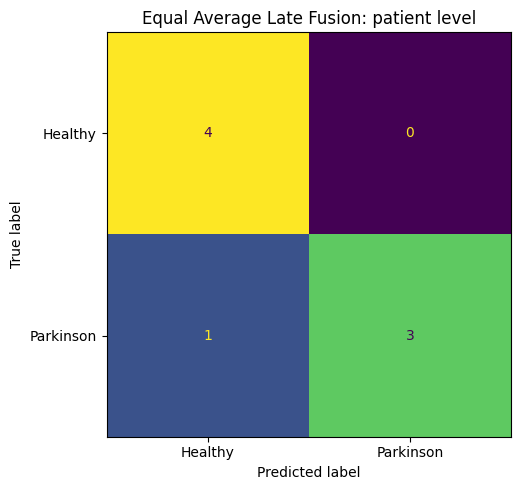

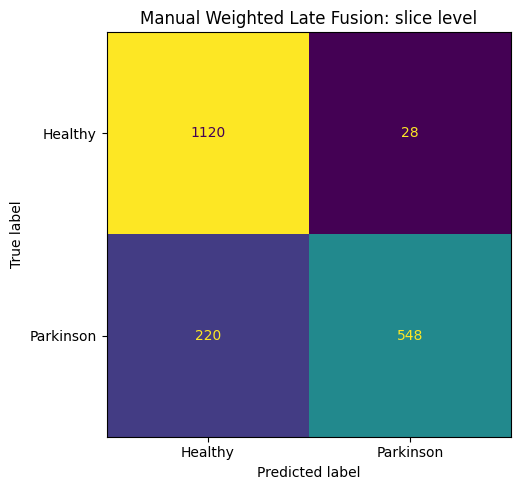

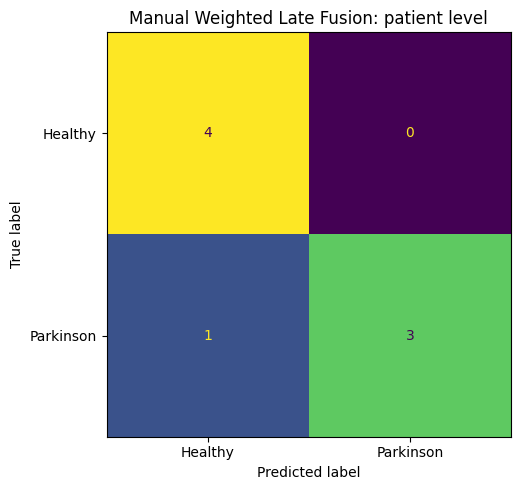

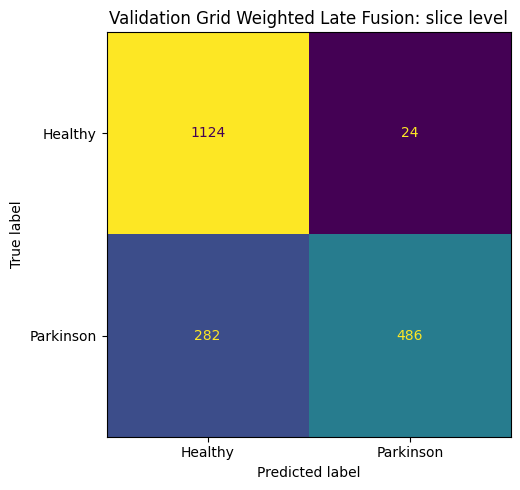

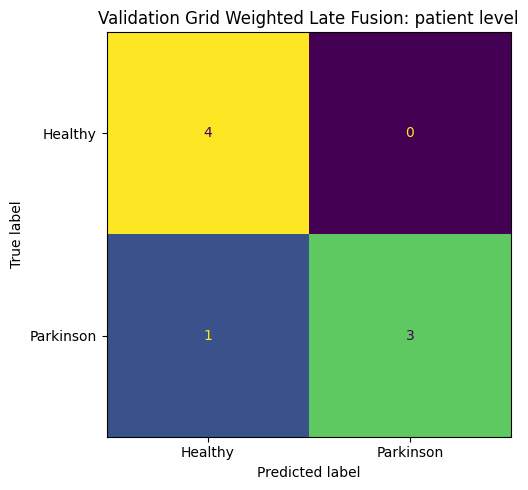

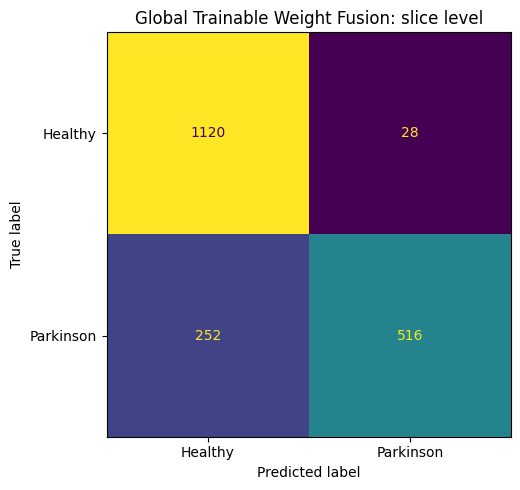

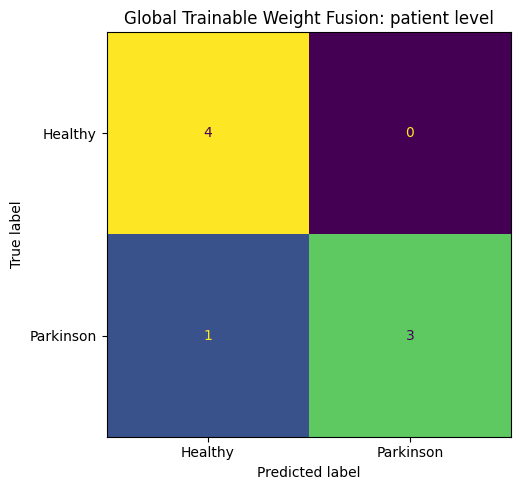

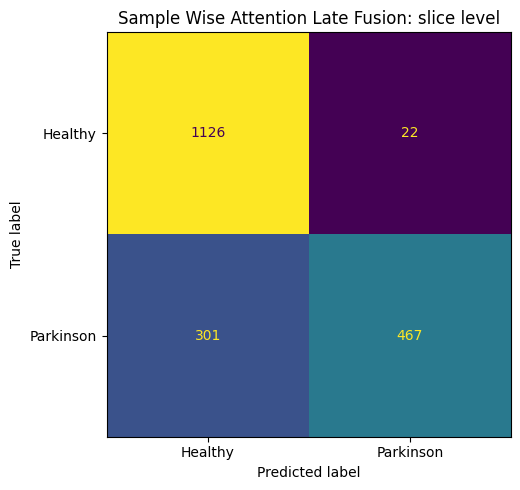

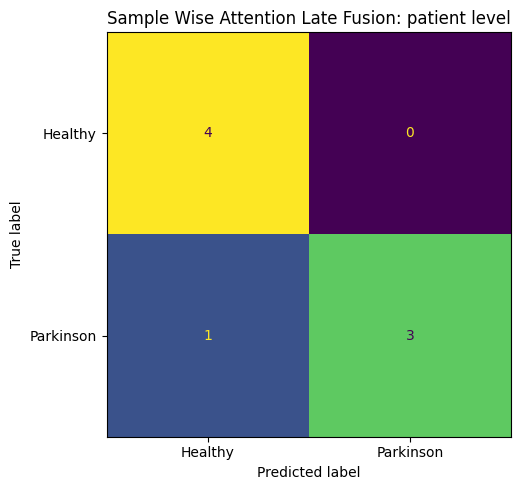

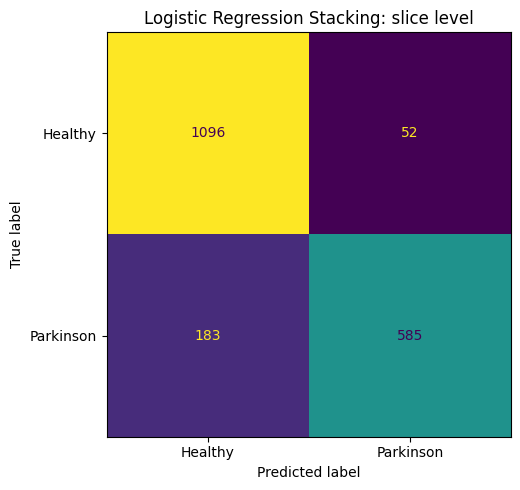

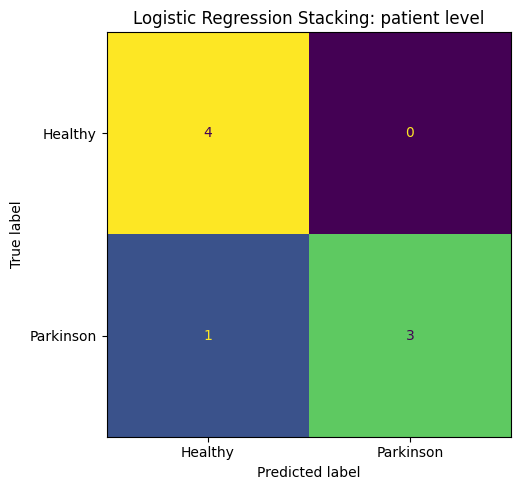

,Method,Test Slices,Test Patients,Slice Accuracy,Slice Precision,Slice Recall,Slice F1,Slice ROC AUC,Patient Accuracy,Patient Precision,Patient Recall,Patient F1,Patient ROC AUC,Threshold,Split Fingerprint
0,Manual Weighted Late Fusion,1916,8,0.870564,0.951389,0.713542,0.815476,0.954068,0.875,1.0,0.75,0.857143,1.0000,0.5,2c8672a648fb8e44d4f9
1,Equal Average Late Fusion,1916,8,0.858559,0.959335,0.675781,0.792972,0.951527,0.875,1.0,0.75,0.857143,1.0000,0.5,2c8672a648fb8e44d4f9
2,Logistic Regression Stacking,1916,8,0.877349,0.918367,0.761719,0.832740,0.950491,0.875,1.0,0.75,0.857143,1.0000,0.5,2c8672a648fb8e44d4f9
3,DenseNet121,1916,8,0.870564,0.884615,0.778646,0.828255,0.950034,0.875,1.0,0.75,0.857143,1.0000,0.5,2c8672a648fb8e44d4f9
4,Global Trainable Weight Fusion,1916,8,0.853862,0.948529,0.671875,0.786585,0.948943,0.875,1.0,0.75,0.857143,1.0000,0.5,2c8672a648fb8e44d4f9
5,Validation Grid Weighted Late Fusion,1916,8,0.840292,0.952941,0.632812,0.760563,0.948130,0.875,1.0,0.75,0.857143,1.0000,0.5,2c8672a648fb8e44d4f9
6,Sample Wise Attention Late Fusion,1916,8,0.831420,0.955010,0.608073,0.743039,0.947128,0.875,1.0,0.75,0.857143,1.0000,0.5,2c8672a648fb8e44d4f9
7,MobileNetV2,1916,8,0.826722,0.900735,0.638021,0.746951,0.919375,0.875,1.0,0.75,0.857143,1.0000,0.5,2c8672a648fb8e44d4f9
8,VGG16,1916,8,0.805846,0.924893,0.561198,0.698541,0.875569,0.750,1.0,0.50,0.666667,0.9375,0.5,2c8672a648fb8e44d4f9


Best late-fusion method: Manual Weighted Late Fusion


In [30]:
result_rows = []
artifacts = {}

def metrics(y_true, y_prob):
    y_true = np.asarray(y_true, dtype=np.int32).reshape(-1)
    y_prob = np.asarray(y_prob, dtype=np.float64).reshape(-1)

    if len(y_true) != len(y_prob):
        raise ValueError("Length mismatch.")

    if (
        not np.all(np.isfinite(y_prob))
        or np.any(y_prob < 0)
        or np.any(y_prob > 1)
    ):
        raise ValueError("Invalid probabilities.")

    y_pred = (y_prob >= 0.5).astype(np.int32)

    return {
        "accuracy": float(
            accuracy_score(y_true, y_pred)
        ),
        "precision": float(
            precision_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "recall": float(
            recall_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "f1": float(
            f1_score(
                y_true,
                y_pred,
                zero_division=0,
            )
        ),
        "auc": safe_auc(y_true, y_prob),
        "prediction": y_pred,
    }


def save_verified_roc_npz(
    path,
    identifiers,
    y_true,
    y_prob,
    y_pred,
    level_name,
    method_name,
):
    identifiers = np.asarray(
        identifiers
    ).astype(str).reshape(-1)

    y_true = np.asarray(
        y_true,
        dtype=np.int32,
    ).reshape(-1)

    y_prob = np.asarray(
        y_prob,
        dtype=np.float64,
    ).reshape(-1)

    y_pred = np.asarray(
        y_pred,
        dtype=np.int32,
    ).reshape(-1)

    if not (
        len(identifiers)
        == len(y_true)
        == len(y_prob)
        == len(y_pred)
    ):
        raise RuntimeError(
            f"{level_name} ROC NPZ arrays have inconsistent lengths."
        )

    fpr, tpr, thresholds = roc_curve(
        y_true,
        y_prob,
    )

    auc_value = float(
        roc_auc_score(
            y_true,
            y_prob,
        )
    )

    payload = {
        "y_true": y_true,
        "y_prob": y_prob,
        "y_probability": y_prob,
        "y_pred": y_pred,
        "fpr": np.asarray(
            fpr,
            dtype=np.float64,
        ),
        "tpr": np.asarray(
            tpr,
            dtype=np.float64,
        ),
        "thresholds": np.asarray(
            thresholds,
            dtype=np.float64,
        ),
        "auc": np.asarray(
            auc_value,
            dtype=np.float64,
        ),
        "method_name": np.asarray(
            method_name
        ),
        "evaluation_level": np.asarray(
            level_name
        ),
        "split_fingerprint": np.asarray(
            SPLIT_FINGERPRINT
        ),
        "threshold": np.asarray(
            0.5,
            dtype=np.float64,
        ),
        "positive_class": np.asarray(
            "Parkinson"
        ),
        "negative_class": np.asarray(
            "Healthy"
        ),
    }

    if level_name == "patient_level":
        payload["patient_ids"] = identifiers
    else:
        payload["image_paths"] = identifiers

    np.savez_compressed(
        path,
        **payload,
    )

    with np.load(
        path,
        allow_pickle=False,
    ) as check:
        required_keys = {
            "y_true",
            "y_prob",
            "y_probability",
            "y_pred",
            "fpr",
            "tpr",
            "thresholds",
            "auc",
            "method_name",
            "evaluation_level",
            "split_fingerprint",
        }

        if level_name == "patient_level":
            required_keys.add("patient_ids")
        else:
            required_keys.add("image_paths")

        missing_keys = required_keys - set(check.files)

        if missing_keys:
            raise RuntimeError(
                f"{level_name} ROC NPZ is missing keys: {sorted(missing_keys)}"
            )

        if check["y_true"].shape != check["y_prob"].shape:
            raise RuntimeError(
                f"{level_name} ROC NPZ label/probability shapes do not match."
            )

    return str(path)


def save_confusion(y_true, y_pred, title, path):
    figure, axis = plt.subplots(
        figsize=(6, 5)
    )

    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(
            y_true,
            y_pred,
        ),
        display_labels=[
            "Healthy",
            "Parkinson",
        ],
    ).plot(
        ax=axis,
        values_format="d",
        colorbar=False,
    )

    axis.set_title(title)
    figure.tight_layout()
    figure.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)


def evaluate_method(method_name, slice_probability):
    safe_name = re.sub(
        r"[^a-zA-Z0-9]+",
        "_",
        method_name,
    ).strip("_").lower()

    slice_probability = np.asarray(
        slice_probability,
        dtype=np.float32,
    ).reshape(-1)

    slice_result = metrics(
        y_test_slices,
        slice_probability,
    )

    slice_prediction = slice_result.pop(
        "prediction"
    )

    prediction_table = test_table[
        [
            "filepath",
            "filename",
            "patient_id",
            "slice_index",
            "label",
            "class_name",
        ]
    ].copy()

    prediction_table["probability"] = (
        slice_probability
    )

    prediction_table["predicted_label"] = (
        slice_prediction
    )

    prediction_table["correct"] = (
        prediction_table["label"].to_numpy()
        == slice_prediction
    )

    patient_prediction_table = prediction_table.groupby(
        ["patient_id", "label", "class_name"],
        as_index=False,
    ).agg(
        probability=("probability", "mean"),
        median_probability=("probability", "median"),
        slice_count=("filepath", "size"),
    ).sort_values(
        "patient_id"
    ).reset_index(drop=True)

    patient_y_true = patient_prediction_table[
        "label"
    ].to_numpy(dtype=np.int32)

    patient_y_prob = patient_prediction_table[
        "probability"
    ].to_numpy(dtype=np.float32)

    patient_result = metrics(
        patient_y_true,
        patient_y_prob,
    )

    patient_prediction = patient_result.pop(
        "prediction"
    )

    patient_prediction_table["predicted_label"] = (
        patient_prediction
    )

    patient_prediction_table["correct"] = (
        patient_y_true == patient_prediction
    )

    prediction_table.to_csv(
        PREDICTIONS_DIR / f"{safe_name}_slice_predictions.csv",
        index=False,
    )

    patient_prediction_table.to_csv(
        PREDICTIONS_DIR / f"{safe_name}_patient_predictions.csv",
        index=False,
    )

    slice_npz = save_verified_roc_npz(
        ROC_DIR / f"{safe_name}_slice_roc_data.npz",
        identifiers=prediction_table["filepath"].astype(str).to_numpy(),
        y_true=y_test_slices,
        y_prob=slice_probability,
        y_pred=slice_prediction,
        level_name="slice_level",
        method_name=method_name,
    )

    patient_npz = save_verified_roc_npz(
        ROC_DIR / f"{safe_name}_patient_roc_data.npz",
        identifiers=patient_prediction_table["patient_id"].astype(str).to_numpy(),
        y_true=patient_y_true,
        y_prob=patient_y_prob,
        y_pred=patient_prediction,
        level_name="patient_level",
        method_name=method_name,
    )

    report_path = REPORTS_DIR / f"{safe_name}_report.txt"

    report_path.write_text(
        "SLICE LEVEL\n"
        + classification_report(
            y_test_slices,
            slice_prediction,
            target_names=[
                "Healthy",
                "Parkinson",
            ],
            digits=4,
            zero_division=0,
        )
        + "\n\nPATIENT LEVEL\n"
        + classification_report(
            patient_y_true,
            patient_prediction,
            target_names=[
                "Healthy",
                "Parkinson",
            ],
            digits=4,
            zero_division=0,
        ),
        encoding="utf-8",
    )

    save_confusion(
        y_test_slices,
        slice_prediction,
        f"{method_name}: slice level",
        CONFUSION_DIR / f"{safe_name}_slice_confusion.png",
    )

    save_confusion(
        patient_y_true,
        patient_prediction,
        f"{method_name}: patient level",
        CONFUSION_DIR / f"{safe_name}_patient_confusion.png",
    )

    row = {
        "Method": method_name,
        "Test Slices": len(y_test_slices),
        "Test Patients": len(patient_y_true),
        "Slice Accuracy": slice_result["accuracy"],
        "Slice Precision": slice_result["precision"],
        "Slice Recall": slice_result["recall"],
        "Slice F1": slice_result["f1"],
        "Slice ROC AUC": slice_result["auc"],
        "Patient Accuracy": patient_result["accuracy"],
        "Patient Precision": patient_result["precision"],
        "Patient Recall": patient_result["recall"],
        "Patient F1": patient_result["f1"],
        "Patient ROC AUC": patient_result["auc"],
        "Threshold": 0.5,
        "Split Fingerprint": SPLIT_FINGERPRINT,
    }

    result_rows.append(row)

    artifacts[method_name] = {
        "safe_name": safe_name,
        "slice_npz": slice_npz,
        "patient_npz": patient_npz,
        "slice_predictions": prediction_table,
        "patient_predictions": patient_prediction_table,
        "result": row,
    }


for method_name, probability in test_method_probabilities.items():
    evaluate_method(
        method_name,
        probability,
    )

results_df = pd.DataFrame(
    result_rows
).sort_values(
    ["Patient ROC AUC", "Patient F1", "Patient Accuracy", "Slice ROC AUC"],
    ascending=False,
    na_position="last",
).reset_index(drop=True)

results_df.to_csv(
    TABLES_DIR / "corrected_late_fusion_comparison.csv",
    index=False,
)

results_df.to_excel(
    TABLES_DIR / "corrected_late_fusion_comparison.xlsx",
    index=False,
)

BEST_METHOD = str(
    results_df.loc[0, "Method"]
)

display(results_df)

print(
    "Best late-fusion method:",
    BEST_METHOD,
)

## Combined ROC graphs and standard best-result NPZ aliases (with enriched metadata)

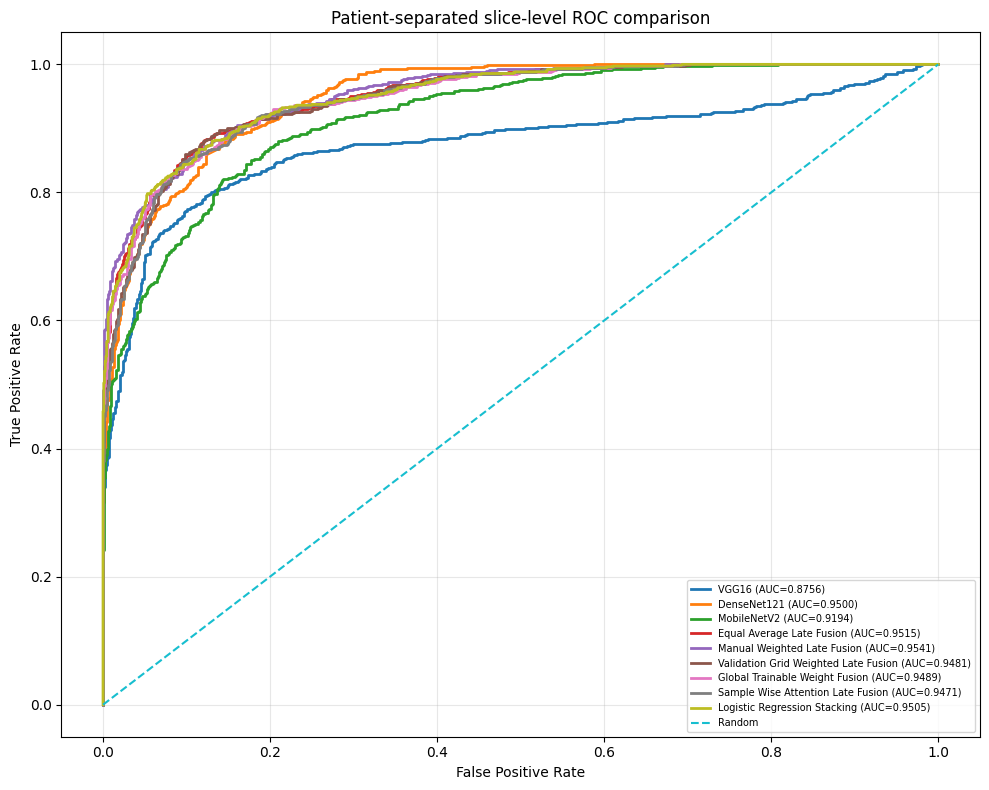

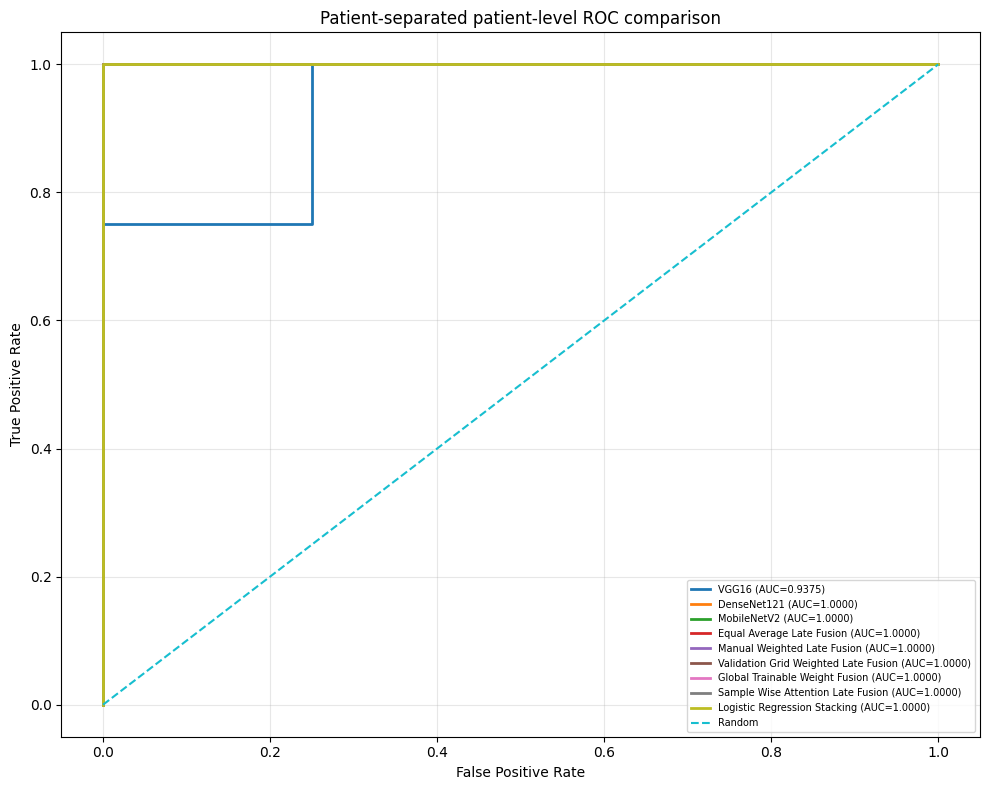

Slice ROC graph: /content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/graphs/corrected_slice_roc_comparison.png
Patient ROC graph: /content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/graphs/corrected_patient_roc_comparison.png
Best patient ROC NPZ alias: /content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/roc_npz/best_late_fusion_patient_roc_data.npz


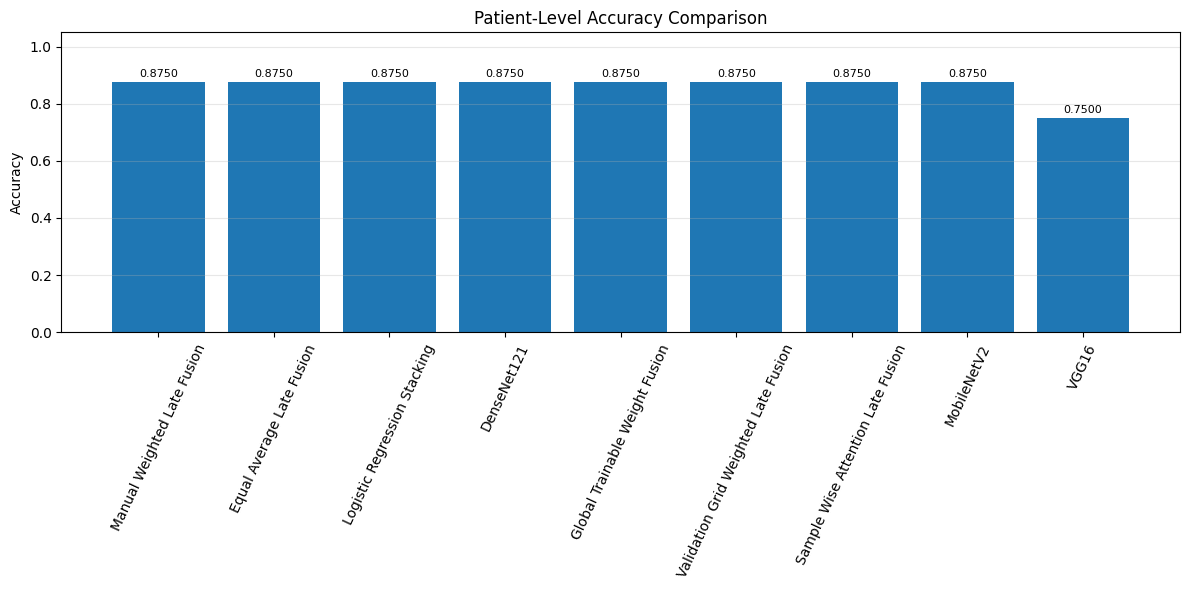

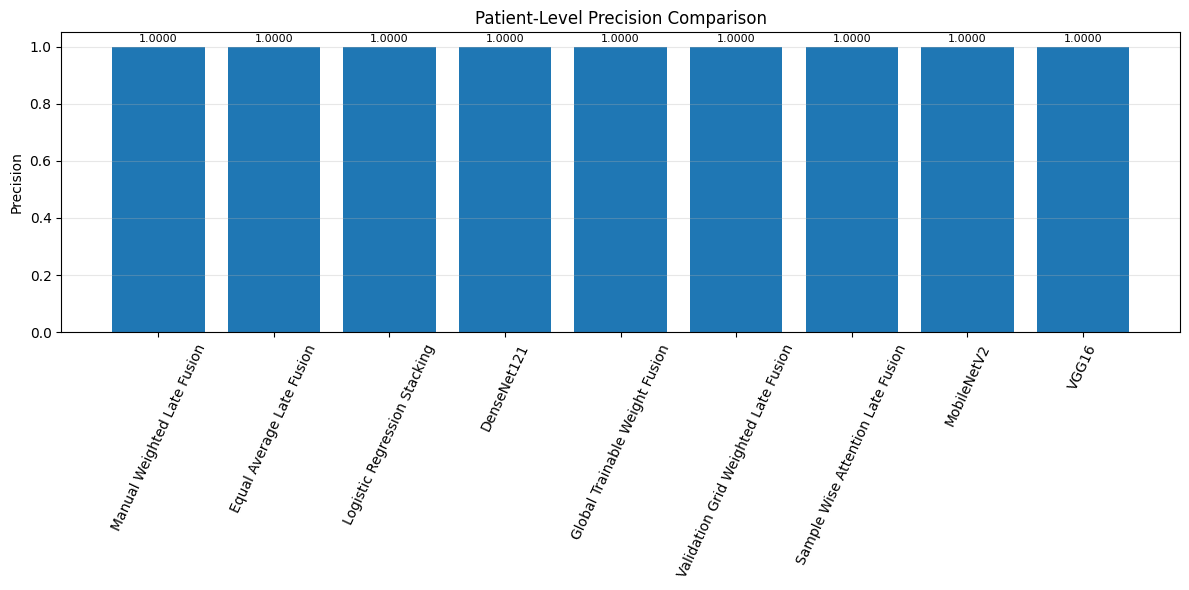

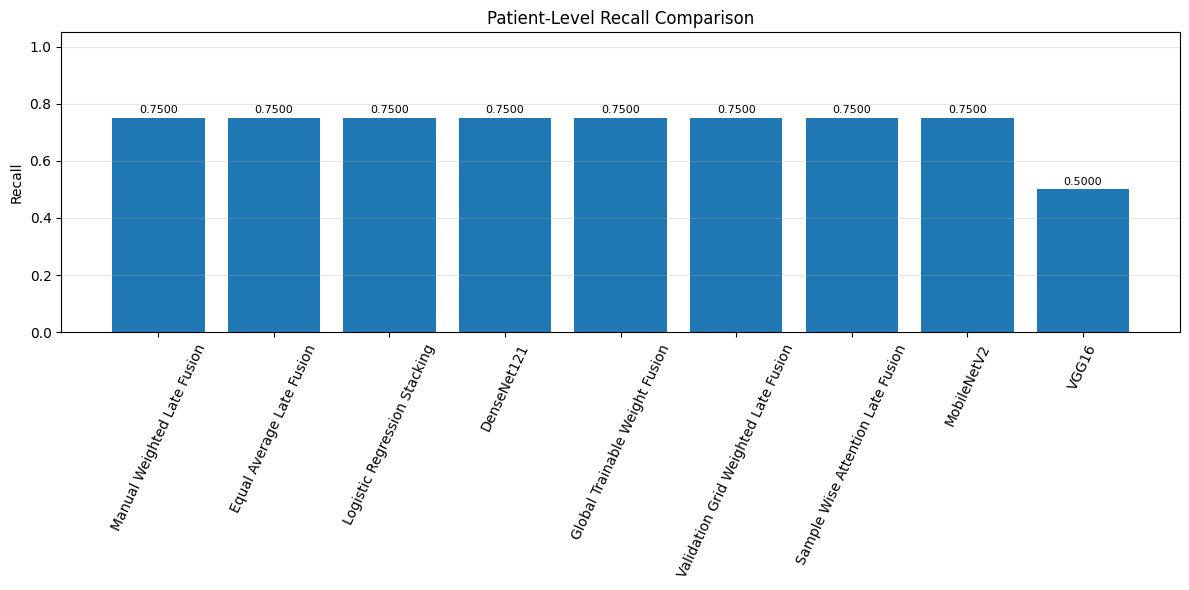

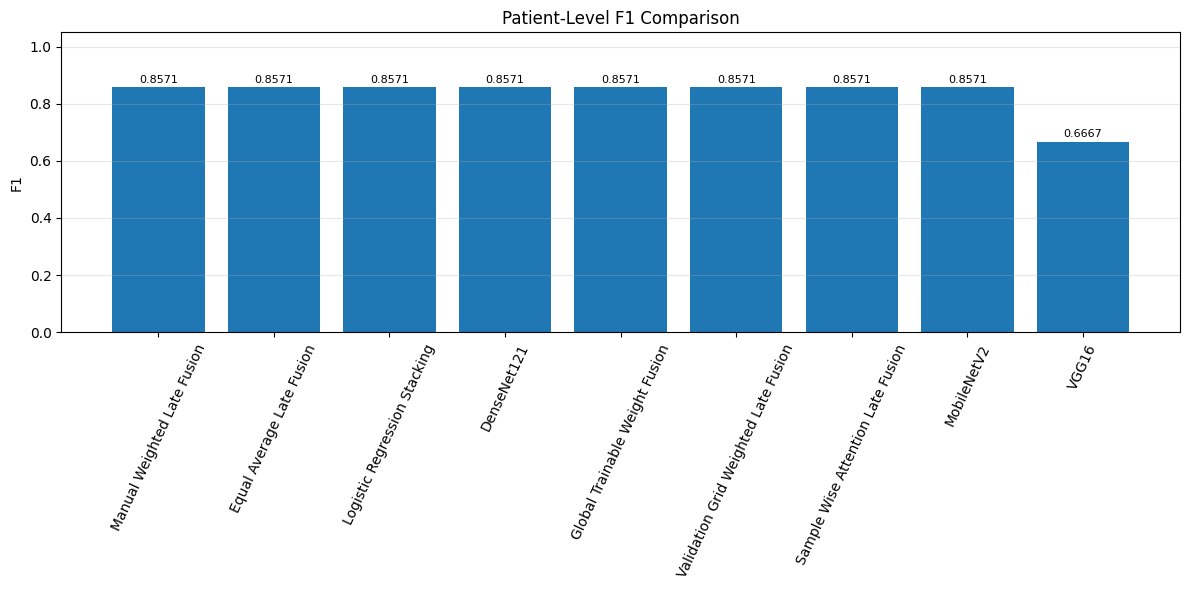

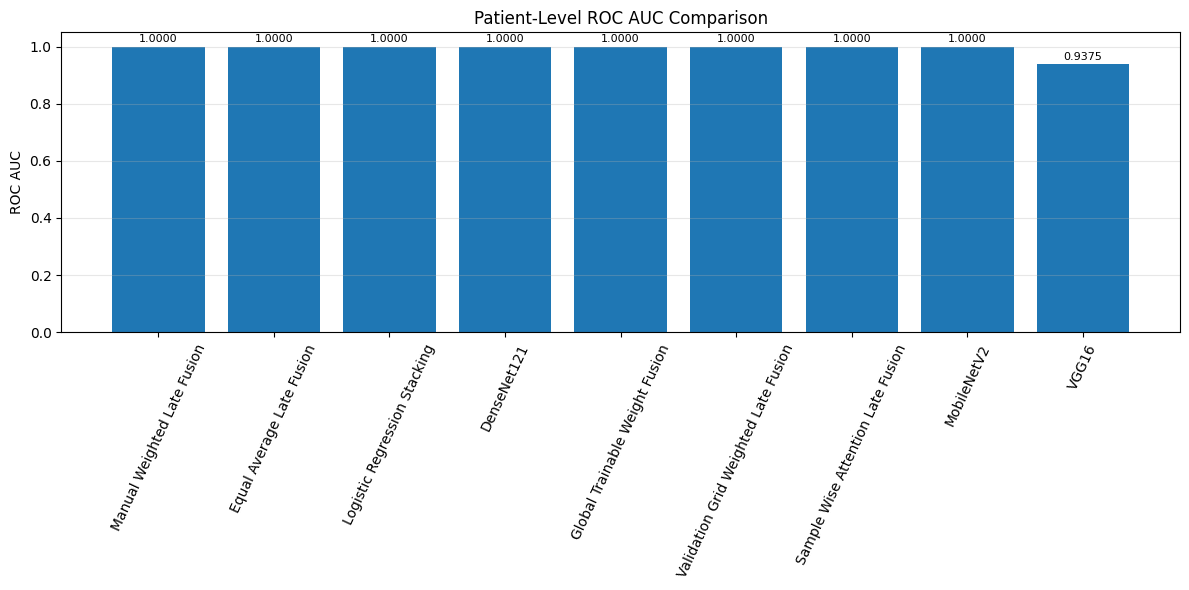

Saved patient-level metric comparison graphs: [PosixPath('/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/graphs/patient_level_accuracy_comparison.png'), PosixPath('/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/graphs/patient_level_precision_comparison.png'), PosixPath('/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/graphs/patient_level_recall_comparison.png'), PosixPath('/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/graphs/patient_level_f1_comparison.png'), PosixPath('/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/graphs/patient_level_roc_auc_comparison.png')]


In [31]:
def plot_roc_level(level):
    figure, axis = plt.subplots(
        figsize=(10, 8)
    )

    for method_name, artifact in artifacts.items():
        path = artifact[f"{level}_npz"]

        with np.load(
            path,
            allow_pickle=False,
        ) as data:
            y_true = data["y_true"]
            y_prob = data["y_prob"]

        fpr, tpr, _ = roc_curve(
            y_true,
            y_prob,
        )

        axis.plot(
            fpr,
            tpr,
            linewidth=2,
            label=(
                f"{method_name} "
                f"(AUC={safe_auc(y_true, y_prob):.4f})"
            ),
        )

    axis.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Random",
    )

    axis.set_xlabel(
        "False Positive Rate"
    )
    axis.set_ylabel(
        "True Positive Rate"
    )
    axis.set_title(
        f"Patient-separated {level}-level ROC comparison"
    )
    axis.grid(alpha=0.3)
    axis.legend(
        loc="lower right",
        fontsize=7,
    )
    figure.tight_layout()

    output = GRAPHS_DIR / f"corrected_{level}_roc_comparison.png"

    figure.savefig(
        output,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    return output


SLICE_ROC_GRAPH = plot_roc_level("slice")
PATIENT_ROC_GRAPH = plot_roc_level("patient")

best_artifact = artifacts[BEST_METHOD]

with np.load(
    best_artifact["slice_npz"],
    allow_pickle=False,
) as data:
    BEST_SLICE_ALIAS = (
        ROC_DIR / "best_late_fusion_slice_roc_data.npz"
    )

    np.savez_compressed(
        BEST_SLICE_ALIAS,
        **{key: data[key] for key in data.files}
    )

with np.load(
    best_artifact["patient_npz"],
    allow_pickle=False,
) as data:
    BEST_PATIENT_ALIAS = (
        ROC_DIR / "best_late_fusion_patient_roc_data.npz"
    )

    np.savez_compressed(
        BEST_PATIENT_ALIAS,
        **{key: data[key] for key in data.files}
    )

print("Slice ROC graph:", SLICE_ROC_GRAPH)
print("Patient ROC graph:", PATIENT_ROC_GRAPH)
print("Best patient ROC NPZ alias:", BEST_PATIENT_ALIAS)


PATIENT_METRIC_GRAPH_PATHS = []

for metric_column, short_name in [
    ("Patient Accuracy", "accuracy"),
    ("Patient Precision", "precision"),
    ("Patient Recall", "recall"),
    ("Patient F1", "f1"),
    ("Patient ROC AUC", "roc_auc"),
]:
    ordered = results_df.sort_values(
        metric_column,
        ascending=False,
    )

    figure, axis = plt.subplots(
        figsize=(12, 6)
    )

    bars = axis.bar(
        ordered["Method"],
        ordered[metric_column],
    )

    axis.set_title(
        f"Patient-Level {metric_column.replace('Patient ', '')} Comparison"
    )
    axis.set_ylabel(
        metric_column.replace(
            "Patient ",
            "",
        )
    )
    axis.set_ylim(0, 1.05)
    axis.tick_params(
        axis="x",
        rotation=65,
    )
    axis.grid(
        axis="y",
        alpha=0.3,
    )

    for bar in bars:
        value = float(
            bar.get_height()
        )

        axis.text(
            bar.get_x()
            + bar.get_width() / 2,
            min(value + 0.01, 1.03),
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=8,
        )

    figure.tight_layout()

    metric_graph_path = (
        GRAPHS_DIR
        / f"patient_level_{short_name}_comparison.png"
    )

    figure.savefig(
        metric_graph_path,
        dpi=300,
        bbox_inches="tight",
    )

    PATIENT_METRIC_GRAPH_PATHS.append(
        metric_graph_path
    )

    plt.show()
    plt.close(figure)

print(
    "Saved patient-level metric comparison graphs:",
    PATIENT_METRIC_GRAPH_PATHS,
)


## Validated single-model and weighted-ensemble Grad-CAM

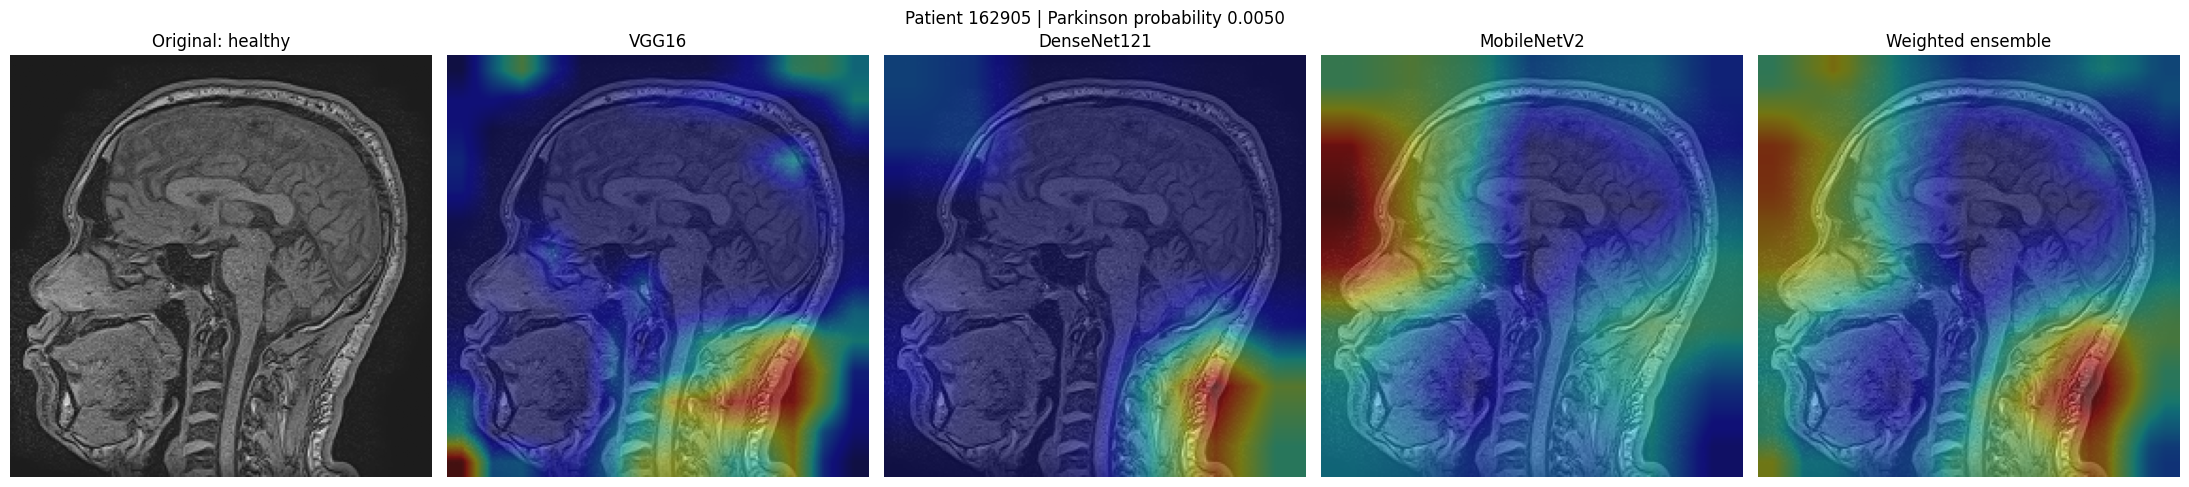

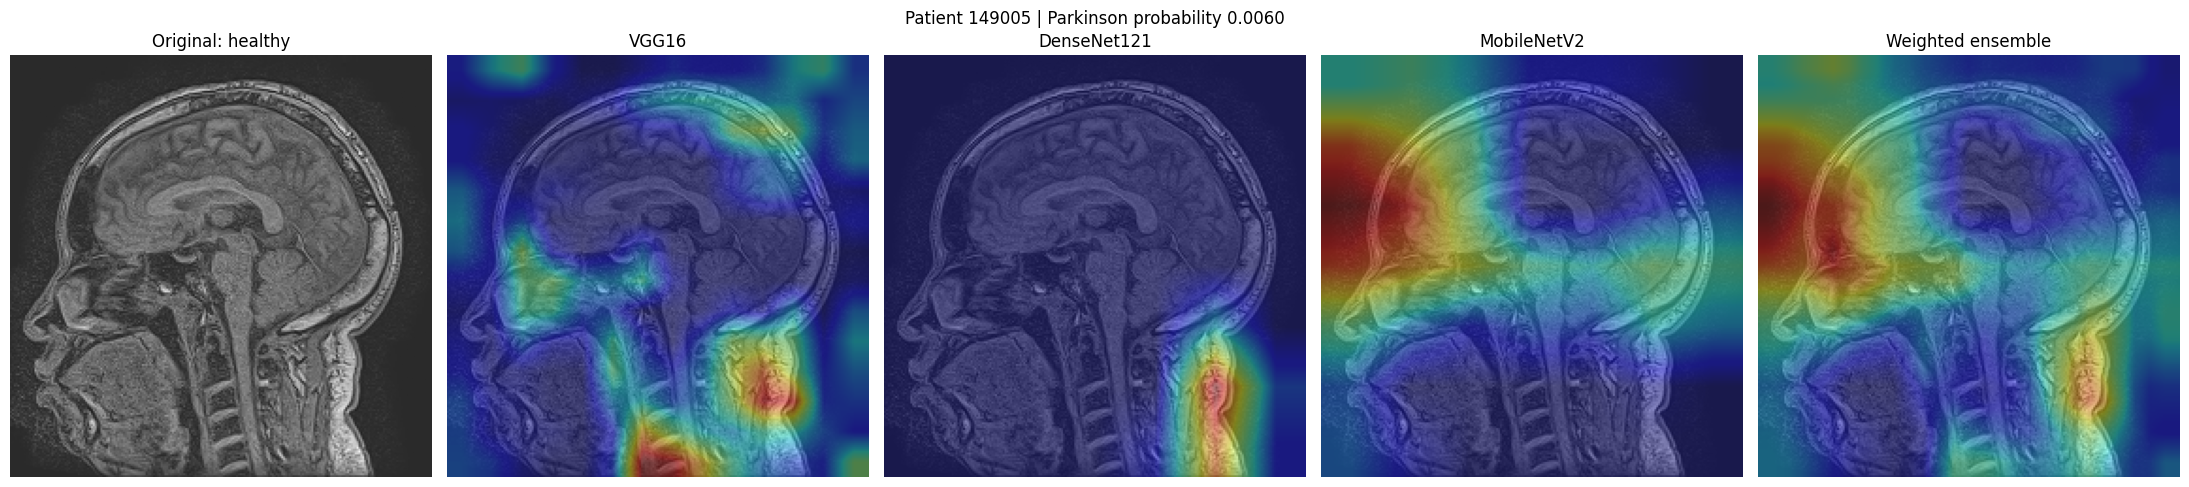

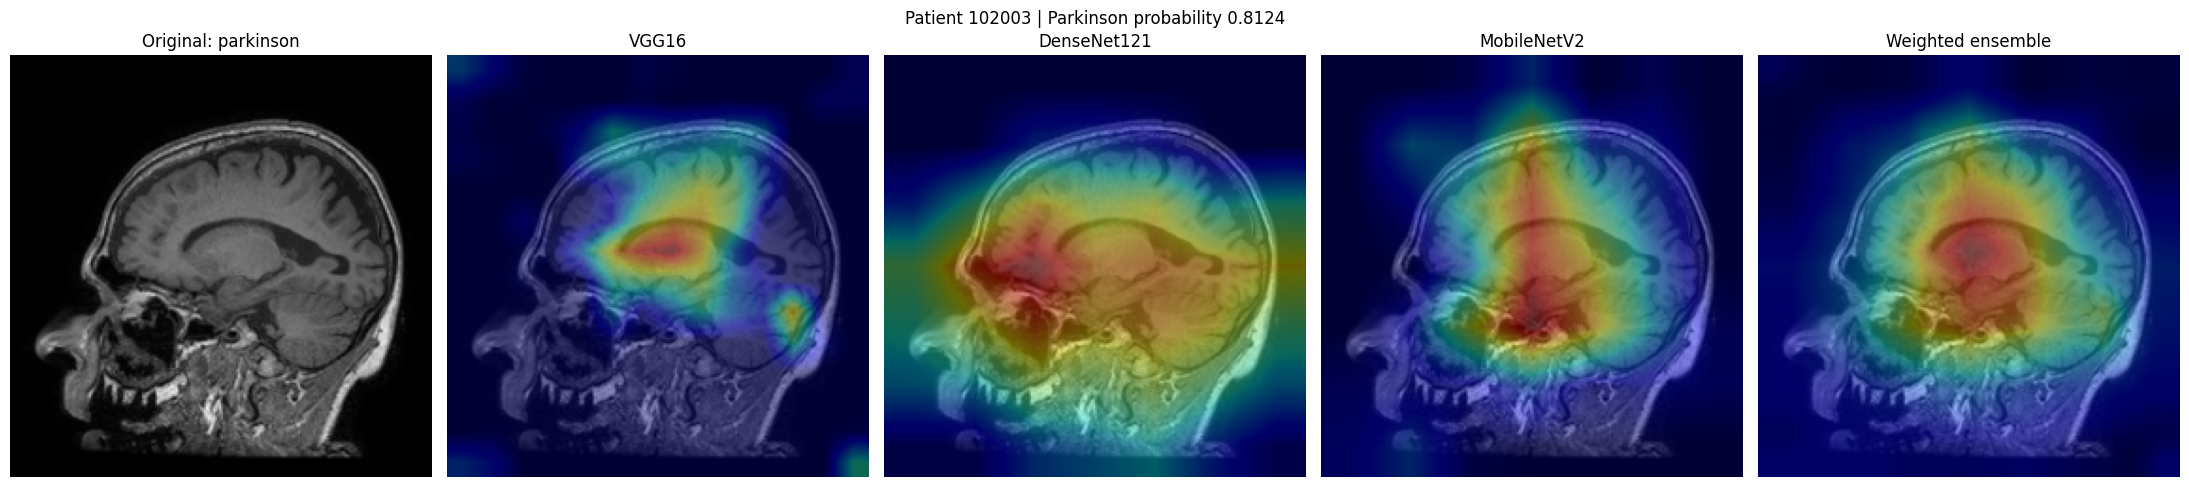

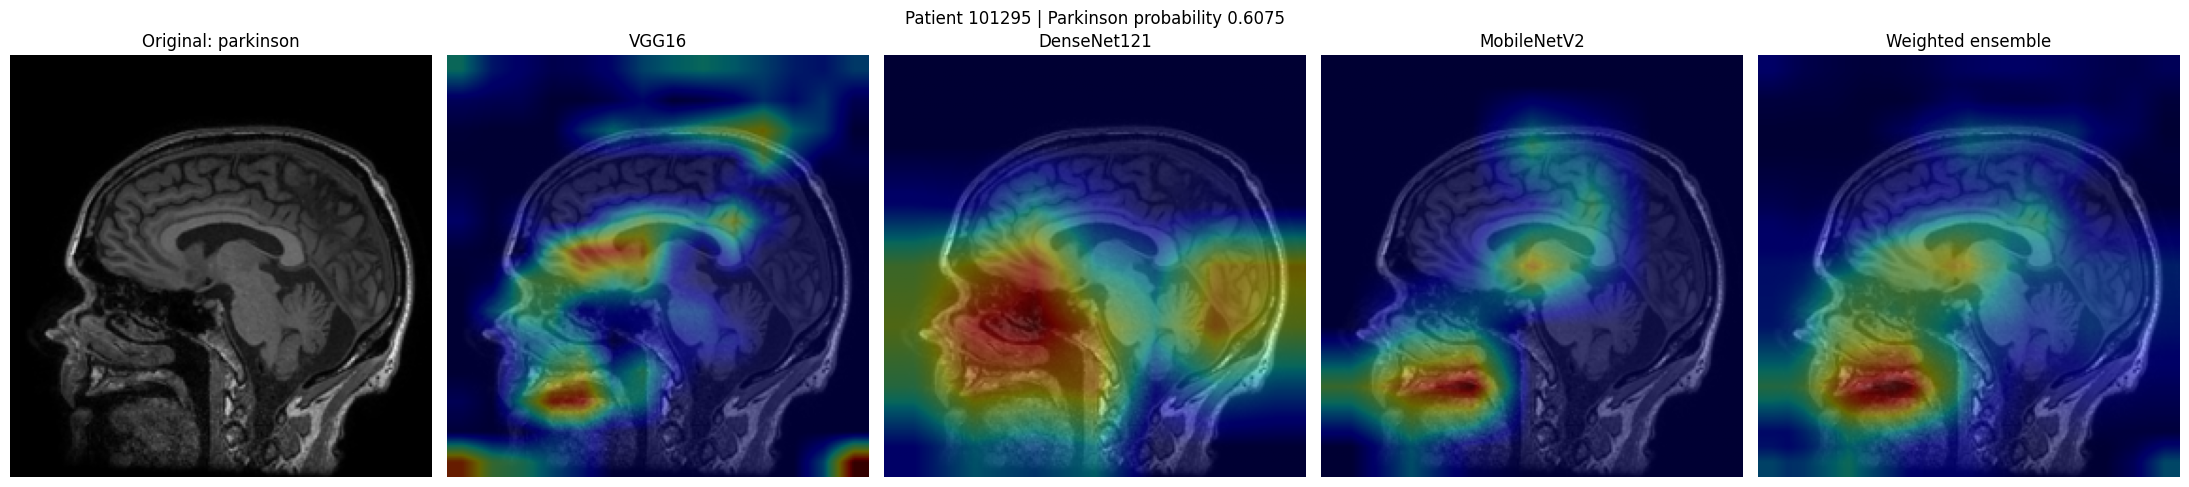

,class,example,patient_id,image_path,png_path,npz_path,vgg16_gradient_norm,densenet121_gradient_norm,mobilenetv2_gradient_norm
0,healthy,1,162905,/content/drive/MyDrive/Patient_level_late_fusi...,/content/drive/MyDrive/Patient_level_late_fusi...,/content/drive/MyDrive/Patient_level_late_fusi...,0.486854,4.766291,0.834104
1,healthy,2,149005,/content/drive/MyDrive/Patient_level_late_fusi...,/content/drive/MyDrive/Patient_level_late_fusi...,/content/drive/MyDrive/Patient_level_late_fusi...,0.471215,5.025635,0.949478
2,parkinson,1,102003,/content/drive/MyDrive/Patient_level_late_fusi...,/content/drive/MyDrive/Patient_level_late_fusi...,/content/drive/MyDrive/Patient_level_late_fusi...,0.483752,5.734316,1.020105
3,parkinson,2,101295,/content/drive/MyDrive/Patient_level_late_fusi...,/content/drive/MyDrive/Patient_level_late_fusi...,/content/drive/MyDrive/Patient_level_late_fusi...,0.480419,4.622839,0.929773


In [32]:
GRADCAM_CONFIG = {
    "VGG16": (
        "vgg16_preprocess",
        ["block5_conv3", "block5_conv2", "block5_conv1"]
    ),
    "DenseNet121": (
        "densenet121_preprocess",
        ["conv5_block16_2_conv", "conv5_block16_1_conv",
         "conv5_block15_2_conv"]
    ),
    "MobileNetV2": (
        "mobilenetv2_preprocess",
        ["Conv_1", "block_16_project", "block_15_project"]
    )
}

HEAD_LAYERS = [
    "global_average_pooling",
    "head_batch_norm",
    "head_dropout_1",
    "head_dense_256",
    "head_dropout_2",
    "prediction"
]

def forward_head(model, backbone_output):
    value = backbone_output
    for layer_name in HEAD_LAYERS:
        layer = model.get_layer(layer_name)
        if isinstance(layer, (layers.Dropout, layers.BatchNormalization)):
            value = layer(value, training=False)
        else:
            value = layer(value)
    return value

def gradcam(model, model_name, image_tensor, target_class):
    preprocess_name, candidates = GRADCAM_CONFIG[model_name]
    preprocess = model.get_layer(preprocess_name)
    backbone = find_backbone(model, model_name)
    last_error = None

    for conv_name in candidates:
        try:
            conv_layer = backbone.get_layer(conv_name)
            feature_model = keras.Model(
                backbone.input,
                [conv_layer.output, backbone.output]
            )

            with tf.GradientTape() as tape:
                conv_output, backbone_output = feature_model(
                    preprocess(image_tensor),
                    training=False
                )
                tape.watch(conv_output)
                prediction = forward_head(model, backbone_output)
                probability = tf.clip_by_value(
                    prediction[:, 0],
                    1e-7,
                    1 - 1e-7
                )
                logit = tf.math.log(probability / (1 - probability))
                score = logit if int(target_class) == 1 else -logit

            gradients = tape.gradient(score, conv_output)
            if gradients is None:
                raise ValueError("Gradient is None.")

            gradient_norm = float(
                tf.linalg.global_norm([gradients]).numpy()
            )
            if not np.isfinite(gradient_norm) or gradient_norm <= 1e-12:
                raise ValueError("Invalid gradient norm.")

            pooled = tf.reduce_mean(gradients, axis=(0, 1, 2))
            heatmap = tf.nn.relu(
                tf.reduce_sum(conv_output[0] * pooled, axis=-1)
            ).numpy()

            maximum = float(np.max(heatmap))
            if not np.all(np.isfinite(heatmap)) or maximum <= 1e-12:
                raise ValueError("Empty heatmap.")

            return {
                "heatmap": (heatmap / maximum).astype(np.float32),
                "layer": conv_name,
                "gradient_norm": gradient_norm
            }
        except Exception as error:
            last_error = error

    raise RuntimeError(f"{model_name} Grad-CAM failed: {last_error}")

def load_image_tensor(path):
    image = Image.open(path).convert("RGB").resize(
        (IMG_SIZE[1], IMG_SIZE[0])
    )
    return tf.convert_to_tensor(
        np.asarray(image, dtype=np.float32)[None, ...]
    )

def resize_heatmap(heatmap):
    return tf.image.resize(
        heatmap[None, ..., None],
        IMG_SIZE
    )[0, :, :, 0].numpy()

def overlay_image(path, heatmap, alpha=0.40):
    image = Image.open(path).convert("RGB").resize(
        (IMG_SIZE[1], IMG_SIZE[0])
    )
    original = np.asarray(image, dtype=np.float32) / 255.0
    heatmap = resize_heatmap(heatmap)
    colored = plt.colormaps["jet"](heatmap)[..., :3]
    overlay = np.clip((1 - alpha) * original + alpha * colored, 0, 1)
    return original, overlay, heatmap

best_predictions = artifacts[BEST_METHOD]["slice_predictions"].copy()
candidates = best_predictions[best_predictions["correct"]].copy()
candidates["confidence"] = np.where(
    candidates["label"] == 1,
    candidates["probability"],
    1 - candidates["probability"]
)
patient_median = candidates.groupby("patient_id")[
    "slice_index"
].transform("median")
candidates["central_distance"] = (
    candidates["slice_index"] - patient_median
).abs().fillna(np.inf)

gradcam_rows = []

for target_label, class_name in [(0, "healthy"), (1, "parkinson")]:
    class_candidates = candidates[
        candidates["label"] == target_label
    ].sort_values(
        ["central_distance", "confidence"],
        ascending=[True, False]
    ).drop_duplicates("patient_id")

    completed = 0

    for _, row in class_candidates.iterrows():
        try:
            image_tensor = load_image_tensor(row["filepath"])
            branch = {
                name: gradcam(
                    model,
                    name,
                    image_tensor,
                    target_label
                )
                for name, model in base_models.items()
            }

            resized = {
                name: resize_heatmap(result["heatmap"])
                for name, result in branch.items()
            }

            combined = (
                GLOBAL_WEIGHTS[0] * resized["VGG16"]
                + GLOBAL_WEIGHTS[1] * resized["DenseNet121"]
                + GLOBAL_WEIGHTS[2] * resized["MobileNetV2"]
            )
            maximum = float(np.max(combined))
            if not np.all(np.isfinite(combined)) or maximum <= 1e-12:
                raise RuntimeError("Invalid ensemble heatmap.")
            combined = (combined / maximum).astype(np.float32)

            original = np.asarray(
                Image.open(row["filepath"]).convert("RGB").resize(
                    (IMG_SIZE[1], IMG_SIZE[0])
                ),
                dtype=np.float32
            ) / 255.0

            overlays = {}
            for name in BASE_MODEL_NAMES:
                _, overlays[name], _ = overlay_image(
                    row["filepath"],
                    branch[name]["heatmap"]
                )

            ensemble_colored = plt.colormaps["jet"](combined)[..., :3]
            ensemble_overlay = np.clip(
                0.60 * original + 0.40 * ensemble_colored,
                0,
                1
            )

            completed += 1
            figure, axes = plt.subplots(1, 5, figsize=(22, 5))
            axes[0].imshow(original)
            axes[0].set_title(f"Original: {class_name}")
            axes[1].imshow(overlays["VGG16"])
            axes[1].set_title("VGG16")
            axes[2].imshow(overlays["DenseNet121"])
            axes[2].set_title("DenseNet121")
            axes[3].imshow(overlays["MobileNetV2"])
            axes[3].set_title("MobileNetV2")
            axes[4].imshow(ensemble_overlay)
            axes[4].set_title("Weighted ensemble")

            for axis in axes:
                axis.axis("off")

            figure.suptitle(
                f"Patient {row['patient_id']} | "
                f"Parkinson probability {row['probability']:.4f}"
            )
            figure.tight_layout()

            png_path = GRADCAM_DIR / (
                f"late_fusion_gradcam_{class_name}_{completed}.png"
            )
            npz_path = GRADCAM_DIR / (
                f"late_fusion_gradcam_{class_name}_{completed}.npz"
            )

            figure.savefig(png_path, dpi=300, bbox_inches="tight")
            plt.show()
            plt.close(figure)

            np.savez_compressed(
                npz_path,
                vgg16_heatmap=resized["VGG16"],
                densenet121_heatmap=resized["DenseNet121"],
                mobilenetv2_heatmap=resized["MobileNetV2"],
                ensemble_heatmap=combined,
                true_label=np.int32(target_label),
                predicted_label=np.int32(row["predicted_label"]),
                parkinson_probability=np.float32(row["probability"]),
                patient_id=np.array(str(row["patient_id"])),
                image_path=np.array(str(row["filepath"])),
                vgg16_layer=np.array(branch["VGG16"]["layer"]),
                densenet121_layer=np.array(branch["DenseNet121"]["layer"]),
                mobilenetv2_layer=np.array(branch["MobileNetV2"]["layer"]),
                vgg16_gradient_norm=np.float32(
                    branch["VGG16"]["gradient_norm"]
                ),
                densenet121_gradient_norm=np.float32(
                    branch["DenseNet121"]["gradient_norm"]
                ),
                mobilenetv2_gradient_norm=np.float32(
                    branch["MobileNetV2"]["gradient_norm"]
                ),
                global_weights=GLOBAL_WEIGHTS.astype(np.float32)
            )

            gradcam_rows.append({
                "class": class_name,
                "example": completed,
                "patient_id": row["patient_id"],
                "image_path": row["filepath"],
                "png_path": str(png_path),
                "npz_path": str(npz_path),
                "vgg16_gradient_norm": branch["VGG16"]["gradient_norm"],
                "densenet121_gradient_norm": branch["DenseNet121"][
                    "gradient_norm"
                ],
                "mobilenetv2_gradient_norm": branch["MobileNetV2"][
                    "gradient_norm"
                ]
            })

            if completed == 2:
                break

        except Exception as error:
            print("Rejected Grad-CAM candidate:", row["filepath"], error)

    if completed < 2:
        raise RuntimeError(
            f"Only {completed} valid Grad-CAM examples for {class_name}."
        )

gradcam_summary = pd.DataFrame(gradcam_rows)
gradcam_summary.to_csv(TABLES_DIR / "gradcam_summary.csv", index=False)
display(gradcam_summary)

## Final verification

In [33]:
required = [
    FIXED_TEST_PATIENTS_PATH,
    PATIENT_ASSIGNMENT_PATH,
    MASTER_SPLIT_PATH,
    TABLES_DIR / "corrected_late_fusion_comparison.csv",
    TABLES_DIR / "corrected_late_fusion_comparison.xlsx",
    TABLES_DIR / "late_fusion_weights.csv",
    TABLES_DIR / "gradcam_summary.csv",
    SLICE_ROC_GRAPH,
    PATIENT_ROC_GRAPH,
    BEST_SLICE_ALIAS,
    BEST_PATIENT_ALIAS,
    HISTORY_DIR / "global_trainable_weight_fusion_history.csv",
    HISTORY_DIR / "sample_wise_attention_late_fusion_history.csv",
] + PATIENT_METRIC_GRAPH_PATHS

for model_name in BASE_MODEL_NAMES:
    required.append(
        MODELS_DIR / f"{model_name.lower()}_patient_level_best.keras"
    )

for artifact in artifacts.values():
    required.extend(
        [
            Path(artifact["slice_npz"]),
            Path(artifact["patient_npz"]),
            PREDICTIONS_DIR
            / f"{artifact['safe_name']}_slice_predictions.csv",
            PREDICTIONS_DIR
            / f"{artifact['safe_name']}_patient_predictions.csv",
            REPORTS_DIR
            / f"{artifact['safe_name']}_report.txt",
            CONFUSION_DIR
            / f"{artifact['safe_name']}_slice_confusion.png",
            CONFUSION_DIR
            / f"{artifact['safe_name']}_patient_confusion.png",
        ]
    )

for class_name in ["healthy", "parkinson"]:
    for example in [1, 2]:
        required.extend(
            [
                GRADCAM_DIR / f"late_fusion_gradcam_{class_name}_{example}.png",
                GRADCAM_DIR / f"late_fusion_gradcam_{class_name}_{example}.npz",
            ]
        )

verification = []

for path in required:
    path = Path(path)

    row = {
        "filename": path.name,
        "full_path": str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
        "npz_keys": "",
        "npz_loads_successfully": "",
    }

    if path.exists() and path.suffix == ".npz":
        try:
            with np.load(
                path,
                allow_pickle=False,
            ) as data:
                row["npz_keys"] = ", ".join(data.files)
                row["npz_loads_successfully"] = True
        except Exception as error:
            row["npz_loads_successfully"] = False
            row["npz_error"] = str(error)

    verification.append(row)

verification_df = pd.DataFrame(verification)

verification_df.to_csv(
    TABLES_DIR / "final_output_verification.csv",
    index=False,
)

display(verification_df)

if not verification_df["exists"].all():
    raise RuntimeError(
        "Some required outputs are missing."
    )

pz_rows = verification_df[
    verification_df["filename"].str.endswith(".npz")
]

if (
    not npz_rows.empty
    and not npz_rows["npz_loads_successfully"].astype(bool).all()
):
    raise RuntimeError(
        "At least one required NPZ file failed to load."
    )

if TOTAL_BASE_MODEL_EPOCHS != 35:
    raise RuntimeError(
        "Base-model epoch configuration is not 35."
    )

if GLOBAL_FUSION_EPOCHS != 35:
    raise RuntimeError(
        "Global fusion epoch configuration is not 35."
    )

if ATTENTION_FUSION_EPOCHS != 35:
    raise RuntimeError(
        "Attention fusion epoch configuration is not 35."
    )

if sorted(test_patients) != sorted(FIXED_TEST_PATIENT_IDS):
    raise RuntimeError(
        "Final test patients do not match the fixed 8-patient cohort."
    )

summary = {
    "experiment_level": "patient",
    "split_type": "patient_level_fixed_test_reference",
    "split_fingerprint": SPLIT_FINGERPRINT,
    "fixed_test_reference": str(FIXED_TEST_PATIENTS_PATH),
    "fixed_test_patient_count": int(len(test_patients)),
    "development_patient_count": int(len(development_patients)),
    "head_epochs": HEAD_EPOCHS,
    "fine_tune_epochs": FINE_TUNE_EPOCHS,
    "total_base_model_epochs": TOTAL_BASE_MODEL_EPOCHS,
    "global_fusion_epochs": GLOBAL_FUSION_EPOCHS,
    "attention_fusion_epochs": ATTENTION_FUSION_EPOCHS,
    "training_patient_count": int(len(train_patients)),
    "test_patient_ids": sorted([str(value) for value in test_patients]),
    "best_method": BEST_METHOD,
    "best_metrics": artifacts[BEST_METHOD]["result"],
}

(
    SAVE_ROOT / "fixed_test_patient_level_summary.json"
).write_text(
    json.dumps(summary, indent=2),
    encoding="utf-8",
)

print(json.dumps(summary, indent=2))
print("All required outputs exist.")
print("Output folder:", SAVE_ROOT)


,filename,full_path,exists,size_bytes,npz_keys,npz_loads_successfully
0,fixed_test_patient_ids.csv,/content/drive/MyDrive/Patient_level_late_fusi...,True,449,,
1,patient_split_assignments.csv,/content/drive/MyDrive/Patient_level_late_fusi...,True,1964,,
2,parkinson_master_patient_split.csv,/content/drive/MyDrive/Patient_level_late_fusi...,True,3813888,,
3,corrected_late_fusion_comparison.csv,/content/drive/MyDrive/Patient_level_late_fusi...,True,1866,,
4,corrected_late_fusion_comparison.xlsx,/content/drive/MyDrive/Patient_level_late_fusi...,True,6143,,
...,...,...,...,...,...,...
87,late_fusion_gradcam_healthy_2.npz,/content/drive/MyDrive/Patient_level_late_fusi...,True,453645,"vgg16_heatmap, densenet121_heatmap, mobilenetv...",True
88,late_fusion_gradcam_parkinson_1.png,/content/drive/MyDrive/Patient_level_late_fusi...,True,572526,,
89,late_fusion_gradcam_parkinson_1.npz,/content/drive/MyDrive/Patient_level_late_fusi...,True,504475,"vgg16_heatmap, densenet121_heatmap, mobilenetv...",True
90,late_fusion_gradcam_parkinson_2.png,/content/drive/MyDrive/Patient_level_late_fusi...,True,566172,,


{
  "experiment_level": "patient",
  "split_type": "patient_level_fixed_test_reference",
  "split_fingerprint": "2c8672a648fb8e44d4f9",
  "fixed_test_reference": "/content/drive/MyDrive/Patient_level_late_fusion/Patient_level_late_fusion_data_save_here/patient_split/fixed_test_patient_ids.csv",
  "fixed_test_patient_count": 8,
  "development_patient_count": 8,
  "head_epochs": 10,
  "fine_tune_epochs": 25,
  "total_base_model_epochs": 35,
  "global_fusion_epochs": 35,
  "attention_fusion_epochs": 35,
  "training_patient_count": 36,
  "test_patient_ids": [
    "101179",
    "101295",
    "101799",
    "102003",
    "113447",
    "130190",
    "149005",
    "162905"
  ],
  "best_method": "Manual Weighted Late Fusion",
  "best_metrics": {
    "Method": "Manual Weighted Late Fusion",
    "Test Slices": 1916,
    "Test Patients": 8,
    "Slice Accuracy": 0.8705636743215032,
    "Slice Precision": 0.9513888888888888,
    "Slice Recall": 0.7135416666666666,
    "Slice F1": 0.8154761904761905,

## Colab run instructions

1. Open this notebook in Google Colab.
2. Select a GPU runtime.
3. Confirm that `ZIP_PATH` points to your `Parkinson_dataset.zip`.
4. Run all cells from the top.
5. Do not change the eight hard-coded test patient IDs. They are the
   exact patients recovered from your VGG16 patient-level ROC NPZ.
6. The notebook trains:
   - VGG16: 10 frozen + 25 fine-tuning = 35 epochs
   - DenseNet121: 10 frozen + 25 fine-tuning = 35 epochs
   - MobileNetV2: 10 frozen + 25 fine-tuning = 35 epochs
   - Global trainable-weight fusion: 35 epochs
   - Sample-wise attention fusion: 35 epochs
7. Early stopping is disabled, so all configured epochs are expected to run.
8. Checkpoints are written under `/content` during training and copied
   to Google Drive afterward with retries.
9. Use the newly generated `*_patient_roc_data.npz` files for the final
   combined patient-level ROC comparison.

Outputs are saved under:

```text
/content/drive/MyDrive/
Late_fusion_patient_level_fixed_8_patients_35_epochs/
```